# PyPSA Electricity Network Model - TYNDP 2030

This notebook builds an electricity-only network model for Europe based on TYNDP 2024 data for the year 2030.

## Phase 1: Setup & Data Loading

Import necessary libraries and load all data files from `data/open-tyndp/`.

In [1]:
!python3.12 -m pip install --upgrade pip
!python3.12 -m pip install pypsa matplotlib seaborn pandas numpy cartopy

In [2]:
import pandas as pd
import numpy as np
import pypsa
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.append('grid-model')
import importlib
import helpers
importlib.reload(helpers)
from helpers import (
    GENERATOR_CARRIERS, STORAGE_CARRIERS,
    WIND_CARRIERS, SOLAR_CARRIERS,
    HYDRO_ROR_CARRIERS,
    CONVENTIONAL_CARRIERS,
    VRE_CARRIERS, RES_CARRIERS, HYDRO_CARRIERS
)

print(f"PyPSA version: {pypsa.__version__}")
print(f"Generator carriers: {len(GENERATOR_CARRIERS)}")
print(f"Storage carriers: {len(STORAGE_CARRIERS)}")
print(f"Wind carriers: {len(WIND_CARRIERS)}")
print(f"Solar carriers: {len(SOLAR_CARRIERS)}")
print(f"Hydro RoR carriers: {len(HYDRO_ROR_CARRIERS)}")
print(f"Conventional carriers: {len(CONVENTIONAL_CARRIERS)}")

PyPSA version: 1.0.7
Generator carriers: 21
Storage carriers: 5
Wind carriers: 2
Solar carriers: 4
Hydro RoR carriers: 1
Conventional carriers: 15


In [3]:
# Define data directory
DATA_DIR = Path("data/open-tyndp")

# Load all CSV files

# Network topology
buses = pd.read_csv(DATA_DIR / "buses.csv")

# links.csv: the geometry field contains a comma inside a LINESTRING, causing
# pandas to see 11 fields but only 10 header names, so it auto-uses the first
# column as the index and shifts all column names by one.
# Fix: provide 11 explicit names so the columns align correctly.
links = pd.read_csv(
    DATA_DIR / "links.csv",
    names=["link_id", "bus0", "bus1", "voltage", "p_nom", "length",
           "underground", "under_construction", "tags", "geometry_a", "geometry_b"],
    skiprows=1,  # skip original header row
    index_col=0,  # use link_id as index
)

# Capacities and costs (using GROUPED capacities - already aggregated by bus+carrier)
capacities = pd.read_csv(DATA_DIR / "pemmdb_capacities_2030_grouped.csv")
costs = pd.read_csv(DATA_DIR / "costs_2030_processed.csv")
technologies = pd.read_csv(DATA_DIR / "technologies_2030.csv")

# Demand
electricity_demand = pd.read_csv(DATA_DIR / "electricity_demand_2030.csv", index_col=0, parse_dates=True)

# Availability profiles for renewables
wind_onshore = pd.read_csv(DATA_DIR / "pecd_data_Wind_Onshore_2030.csv", index_col=0, parse_dates=True)
wind_offshore = pd.read_csv(DATA_DIR / "pecd_data_Wind_Offshore_2030_mapped.csv", index_col=0, parse_dates=True)
solar_utility = pd.read_csv(DATA_DIR / "pecd_data_LFSolarPVUtility_2030.csv", index_col=0, parse_dates=True)
solar_rooftop = pd.read_csv(DATA_DIR / "pecd_data_LFSolarPVRooftop_2030.csv", index_col=0, parse_dates=True)

# Availability profile for thermal/synchronous generators
thermal_avail = pd.read_csv(DATA_DIR / "avail_profile_s_all.csv", index_col=0, parse_dates=True)

# Hydro inflows (5 types)
hydro_ror = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_Run_of_River_2030.csv", index_col=0, parse_dates=True)
hydro_reservoir = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_Reservoir_2030.csv", index_col=0, parse_dates=True)
hydro_pondage = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_Pondage_2030.csv", index_col=0, parse_dates=True)
hydro_ps_open = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_PS_Open_2030.csv", index_col=0, parse_dates=True)
hydro_ps_closed = pd.read_csv(DATA_DIR / "hydro_inflows_tyndp_PS_Closed_2030.csv", index_col=0, parse_dates=True)

# CO2 totals (for validation)
co2_totals = pd.read_csv(DATA_DIR / "co2_totals.csv")

print("  All data files loaded successfully!\n")

# Display basic info
print(f"  Data Summary:")
print(f"   Buses: {len(buses)} nodes")
print(f"   Links: {len(links)} connections")
print(f"   Capacities: {len(capacities)} rows × {len(capacities.columns)} technologies")
print(f"   Demand timesteps: {len(electricity_demand)}")
print(f"   Wind onshore timesteps: {len(wind_onshore)}")
print(f"   Wind offshore timesteps: {len(wind_offshore)}")
print(f"   Solar utility timesteps: {len(solar_utility)}")
print(f"   Solar rooftop timesteps: {len(solar_rooftop)}")
print(f"   Thermal availability timesteps: {len(thermal_avail)}")


  All data files loaded successfully!

  Data Summary:
   Buses: 55 nodes
   Links: 219 connections
   Capacities: 2010 rows × 9 technologies
   Demand timesteps: 8760
   Wind onshore timesteps: 8760
   Wind offshore timesteps: 8760
   Solar utility timesteps: 8760
   Solar rooftop timesteps: 8760
   Thermal availability timesteps: 8760


## Phase 2: Network Topology

Create PyPSA network and add buses (nodes) and transmission lines.

In [4]:
# Create PyPSA network
network = pypsa.Network()
network.name = "TYNDP2024_Electricity_2030"

# Set snapshots - we'll start with a single snapshot, then expand in Phase 6
network.set_snapshots(pd.date_range('2030-01-01', periods=1, freq='h'))

print(f"  Created network: {network.name}")
print(f"   Initial snapshots: {len(network.snapshots)}")

  Created network: TYNDP2024_Electricity_2030
   Initial snapshots: 1


In [5]:
# Inspect buses data structure
print("  Buses data structure:")
print(buses.head())
print(f"\nColumns: {buses.columns.tolist()}")
print(f"\nSample bus codes: {buses['bus_id'].head(10).tolist()}")

  Buses data structure:
  bus_id station_id  voltage  dc      symbol under_construction  tags  \
0   AL00       AL00      380 NaN  Substation                  f  AL00   
1   AT00       AT00      380 NaN  Substation                  f  AT00   
2   BA00       BA00      380 NaN  Substation                  f  BA00   
3   BE00       BE00      380 NaN  Substation                  f  BE00   
4   BG00       BG00      380 NaN  Substation                  f  BG00   

           x          y country                                       geometry  
0  20.036884  41.117588      AL  POINT (20.036883988642362 41.117587702511265)  
1  14.822183  47.668898      AT   POINT (14.822183225330722 47.66889815500067)  
2  17.867837  43.982016      BA   POINT (17.867837381251395 43.98201574415204)  
3   4.967931  50.470635      BE     POINT (4.96793113501169 50.47063494467691)  
4  25.323948  42.668760      BG   POINT (25.323948321769798 42.66875960983357)  

Columns: ['bus_id', 'station_id', 'voltage', 'dc',

In [6]:
# Add buses to network
for idx, row in buses.iterrows():
    network.add("Bus",
                name=row['bus_id'],
                x=row['x'],
                y=row['y'],
                country=row['country'],
                carrier='AC',
                v_nom=row.get('voltage', 380))  # nominal voltage in kV

print(f"Added {len(network.buses)} buses to network")
print(f"\nSample buses:")
print(network.buses.head())


Added 55 buses to network

Sample buses:
      v_nom type          x          y carrier unit location  v_mag_pu_set  \
name                                                                         
AL00  380.0       20.036884  41.117588      AC                         1.0   
AT00  380.0       14.822183  47.668898      AC                         1.0   
BA00  380.0       17.867837  43.982016      AC                         1.0   
BE00  380.0        4.967931  50.470635      AC                         1.0   
BG00  380.0       25.323948  42.668760      AC                         1.0   

      v_mag_pu_min  v_mag_pu_max control generator sub_network country  
name                                                                    
AL00           0.0           inf      PQ                            AL  
AT00           0.0           inf      PQ                            AT  
BA00           0.0           inf      PQ                            BA  
BE00           0.0           inf      PQ       

In [7]:
# Inspect links data structure
print("Links data structure:")
display(links.head(10))
print(f"\nColumns: {links.columns.tolist()}")
print(f"\nLink types: {links['carrier'].unique() if 'carrier' in links.columns else 'No carrier column'}")

Links data structure:


,bus0,bus1,voltage,p_nom,length,underground,under_construction,tags,geometry_a,geometry_b
link_id,,,,,,,,,,
AL00-GR00-DC,AL00,GR00,380,600,219635.110617,t,f,AL00 -> GR00,'LINESTRING (20.036883988642362 41.11758770251...,21.529612363362705 39.48616951026592)'
AL00-ME00-DC,AL00,ME00,380,400,189342.890082,t,f,AL00 -> ME00,'LINESTRING (20.036883988642362 41.11758770251...,19.082581244926107 42.67587451024281)'
AL00-MK00-DC,AL00,MK00,380,500,153308.706607,t,f,AL00 -> MK00,'LINESTRING (20.036883988642362 41.11758770251...,21.73596299130559 41.612799248609235)'
AL00-RS00-DC,AL00,RS00,380,250,351420.535321,t,f,AL00 -> RS00,'LINESTRING (20.036883988642362 41.11758770251...,20.844931029154555 44.22438574020019)'
AT00-CH00-DC,AT00,CH00,380,1200,494893.193612,t,f,AT00 -> CH00,'LINESTRING (14.822183225330722 47.66889815500067,8.416155547862315 46.797090406754855)'
AT00-CZ00-DC,AT00,CZ00,380,900,239946.178070,t,f,AT00 -> CZ00,'LINESTRING (14.822183225330722 47.66889815500067,15.66368315845627 49.752662484669656)'
AT00-DE00-DC,AT00,DE00,380,7500,512754.700056,t,f,AT00 -> DE00,'LINESTRING (14.822183225330722 47.66889815500067,10.11340015140031 51.10991486311772)'
AT00-HU00-DC,AT00,HU00,380,800,324765.186895,t,f,AT00 -> HU00,'LINESTRING (14.822183225330722 47.66889815500067,19.07785532036663 47.21439242207342)'
AT00-ITN1-DC,AT00,ITN1,380,875,464387.903281,t,f,AT00 -> ITN1,'LINESTRING (14.822183225330722 47.66889815500067,9.703872107321653 45.440276039583814)'



Columns: ['bus0', 'bus1', 'voltage', 'p_nom', 'length', 'underground', 'under_construction', 'tags', 'geometry_a', 'geometry_b']

Link types: No carrier column


In [8]:
# Add DC links (HVDC) to network
added_links = 0
skipped_links = 0
skipped_zero_pnom = 0

for link_id_full, row in links.iterrows():
    bus0 = row['bus0']
    bus1 = row['bus1']
    p_nom = row['p_nom']

    # Skip links with zero capacity — they contribute nothing but block the solver
    if p_nom <= 0:
        skipped_zero_pnom += 1
        continue

    # Check if both buses exist in the network
    if bus0 not in network.buses.index or bus1 not in network.buses.index:
        skipped_links += 1
        continue

    network.add("Link",
                name=link_id_full,
                bus0=bus0,
                bus1=bus1,
                p_nom=p_nom,
                length=row['length'] / 1000,  # m → km
                carrier='DC',
                efficiency=0.97,
                p_nom_extendable=False,
                )
    added_links += 1

print(f"Added   : {added_links} DC links")
print(f"Skipped : {skipped_zero_pnom} links with p_nom=0")
if skipped_links > 0:
    print(f"Skipped : {skipped_links} links (bus not in network)")

Added   : 209 DC links
Skipped : 10 links with p_nom=0


In [9]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(network.links.head(10))

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_set,p_min_pu,p_max_pu,capital_cost,marginal_cost,marginal_cost_quadratic,stand_by_cost,length,terrain_factor,committable,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AL00-GR00-DC,AL00,GR00,,DC,0.97,True,0,inf,600.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,219.635111,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
AL00-ME00-DC,AL00,ME00,,DC,0.97,True,0,inf,400.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,189.342890,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
AL00-MK00-DC,AL00,MK00,,DC,0.97,True,0,inf,500.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,153.308707,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
AL00-RS00-DC,AL00,RS00,,DC,0.97,True,0,inf,250.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,351.420535,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
AT00-CH00-DC,AT00,CH00,,DC,0.97,True,0,inf,1200.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,494.893194,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
AT00-CZ00-DC,AT00,CZ00,,DC,0.97,True,0,inf,900.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,239.946178,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
AT00-DE00-DC,AT00,DE00,,DC,0.97,True,0,inf,7500.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,512.754700,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
AT00-HU00-DC,AT00,HU00,,DC,0.97,True,0,inf,800.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,324.765187,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
AT00-ITN1-DC,AT00,ITN1,,DC,0.97,True,0,inf,875.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,464.387903,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0


In [10]:
network.links[network.links.index.str.contains("FR15")]


,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_set,p_min_pu,p_max_pu,capital_cost,marginal_cost,marginal_cost_quadratic,stand_by_cost,length,terrain_factor,committable,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
FR15-ITCO-DC,FR15,ITCO,,DC,0.97,True,0,inf,120.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0
ITCO-FR15-DC,ITCO,FR15,,DC,0.97,True,0,inf,150.0,0.0,False,0.0,inf,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,False,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0,0.0


## Phase 3: Add Carriers

Adding diffrenet types of carriers with their co2 emissions.

In [11]:
# ==========================================
# ADD CARRIERS WITH CO2 EMISSIONS
# ==========================================

# Add infrastructure carriers (AC buses + DC links) — no CO2 emissions
network.add("Carrier", "AC", nice_name="AC Grid", color="#d4af37")
network.add("Carrier", "DC", nice_name="DC Link", color="#a0a0a0")

# Load technologies dataset with pypsa_carrier and CO2 emissions
technologies = pd.read_csv('data/open-tyndp/technologies_2030.csv')

# Get unique carriers with their CO2 emissions
carriers_df = technologies[['pypsa_carrier', 'co2_tco2_mwh']].drop_duplicates()

print(f"Adding {len(carriers_df)} carriers to the network...")
print(f"\nCarriers: {sorted(carriers_df['pypsa_carrier'].unique())}\n")

# Add each carrier to the network
for _, row in carriers_df.iterrows():
    carrier_name = row['pypsa_carrier']
    co2_emissions = row['co2_tco2_mwh']  # tCO2/MWh_electric (already accounts for efficiency)

    # Determine nice_name and color based on carrier type
    if carrier_name in ['onwind', 'offwind']:
        color = '#3B6182'  # Blue for wind
        nice_name = 'Wind ' + carrier_name.replace('wind', '').replace('on', 'Onshore').replace('off', 'Offshore')
    elif 'solar' in carrier_name:
        color = '#FFDD00'  # Yellow for solar
        nice_name = carrier_name.replace('-', ' ').title()
    elif 'hydro' in carrier_name:
        color = '#298c81'  # Teal for hydro
        nice_name = carrier_name.replace('-', ' ').title()
    elif carrier_name == 'battery':
        color = '#b8ea04'  # Light green for battery
        nice_name = 'Battery'
    elif carrier_name == 'electrolyser':
        color = '#ff29d9'  # Pink for electrolyser
        nice_name = 'Electrolyser'
    elif carrier_name == 'gas':
        color = '#d35050'  # Red for gas
        nice_name = 'Gas'
    elif carrier_name == 'gas-ccs':
        color = '#ff9494'  # Light red for gas with CCS
        nice_name = 'Gas CCS'
    elif carrier_name == 'coal':
        color = '#707070'  # Dark grey for coal
        nice_name = 'Coal'
    elif carrier_name == 'coal-ccs':
        color = '#b0b0b0'  # Light grey for coal with CCS
        nice_name = 'Coal CCS'
    elif carrier_name == 'lignite':
        color = '#8b4513'  # Brown for lignite
        nice_name = 'Lignite'
    elif carrier_name == 'lignite-ccs':
        color = '#cd853f'  # Light brown for lignite with CCS
        nice_name = 'Lignite CCS'
    elif carrier_name == 'nuclear':
        color = '#ff6600'  # Orange for nuclear
        nice_name = 'Nuclear'
    elif 'oil' in carrier_name:
        color = '#000000'  # Black for oil
        nice_name = carrier_name.replace('-', ' ').title()
    elif carrier_name == 'h2-ccgt':
        color = "#e861e8"
        nice_name = 'Hydrogen CCGT'
    elif carrier_name == 'h2-fuel-cell':
        color = "#b261e8"
        nice_name = 'H2 Fuel Cell'
    elif carrier_name == 'h2':
        color = '#ea048a'  # Magenta for hydrogen
        nice_name = 'Hydrogen'
    elif carrier_name == 'other-thermal':
        color = '#8B4789'  # Purple for CHP/other thermal
        nice_name = 'Other Thermal'
    else:
        color = '#cccccc'  # Grey for others
        nice_name = carrier_name.replace('-', ' ').title()

    network.add("Carrier",
                carrier_name,
                co2_emissions=co2_emissions,  # tCO2/MWh_electric
                color=color,
                nice_name=nice_name
    )

print(f"Added {len(carriers_df)} carriers to the network")
print(f"\nCarriers in network: {len(network.carriers)}")
print(network.carriers[['co2_emissions', 'color', 'nice_name']])


Adding 33 carriers to the network...

Carriers: ['battery', 'coal', 'coal-ccs', 'electrolyser', 'gas', 'gas-ccs', 'h2-ccgt', 'h2-fuel-cell', 'hydro-phs', 'hydro-phs-pure', 'hydro-pondage', 'hydro-reservoir', 'hydro-ror', 'lignite', 'lignite-ccs', 'nuclear', 'offwind', 'oil-heavy', 'oil-light', 'oil-shale', 'onwind', 'other-res', 'other-thermal', 'solar-pv-rooftop', 'solar-pv-utility', 'solar-thermal', 'solar-thermal-w-storage']

Added 33 carriers to the network

Carriers in network: 29
                         co2_emissions    color                nice_name
name                                                                    
AC                            0.000000  #d4af37                  AC Grid
DC                            0.000000  #a0a0a0                  DC Link
battery                       0.000000  #b8ea04                  Battery
other-thermal                 0.020520  #8B4789            Other Thermal
coal                          0.338400  #707070                     Coa

## Phase 4: Add Generators (Updated)

Now we add generators to the network using:
- Capacities from PEMMDB (already loaded)
- Technology parameters from `technologies_2030.csv` (carrier, efficiency, marginal_cost)
- Generators reference carriers that now exist in the network with CO2 emissions

In [12]:
# Prepare generator data by merging capacities with technology parameters
gen_data = capacities[['bus', 'index_carrier', 'p_nom', 'unit']].copy()

# Look up technology parameters from technologies dataset
gen_data = gen_data.merge(
    technologies[['index_carrier', 'pypsa_carrier', 'efficiency', 'marginal_cost_eur_mwh']],
    on='index_carrier',
    how='left'
)

# Filter out storage units using pypsa_carrier (will be handled separately)
gen_data = gen_data[~gen_data['pypsa_carrier'].isin(STORAGE_CARRIERS)]

print(f"Prepared {len(gen_data)} generators for network")
display(gen_data.head(25))

Prepared 1321 generators for network


,bus,index_carrier,p_nom,unit,pypsa_carrier,efficiency,marginal_cost_eur_mwh
0,AL00,coal,0.00,MW,coal,0.356,129.257155
1,AL00,coal-ccs,0.00,MW,coal-ccs,0.356,32.242818
2,AL00,gas-ccgt,300.00,MW,gas,0.580,79.846115
3,AL00,gas-ccgt-ccs,0.00,MW,gas-ccs,0.580,47.559962
4,AL00,gas-conv,0.00,MW,gas,0.580,79.846115
5,AL00,gas-ocgt,0.00,MW,gas,0.410,111.427700
6,AL00,lignite,0.00,MW,lignite,0.330,147.843745
7,AL00,lignite-ccs,0.00,MW,lignite-ccs,0.330,35.392182
8,AL00,nuclear,0.00,MW,nuclear,0.326,22.319406
9,AL00,oil-heavy,0.00,MW,oil-heavy,0.350,196.071357


In [13]:
display(gen_data.head(25))

,bus,index_carrier,p_nom,unit,pypsa_carrier,efficiency,marginal_cost_eur_mwh
0,AL00,coal,0.00,MW,coal,0.356,129.257155
1,AL00,coal-ccs,0.00,MW,coal-ccs,0.356,32.242818
2,AL00,gas-ccgt,300.00,MW,gas,0.580,79.846115
3,AL00,gas-ccgt-ccs,0.00,MW,gas-ccs,0.580,47.559962
4,AL00,gas-conv,0.00,MW,gas,0.580,79.846115
5,AL00,gas-ocgt,0.00,MW,gas,0.410,111.427700
6,AL00,lignite,0.00,MW,lignite,0.330,147.843745
7,AL00,lignite-ccs,0.00,MW,lignite-ccs,0.330,35.392182
8,AL00,nuclear,0.00,MW,nuclear,0.326,22.319406
9,AL00,oil-heavy,0.00,MW,oil-heavy,0.350,196.071357


In [14]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(gen_data[gen_data["index_carrier"].str.contains("h2", case=False, na=False)])

,bus,index_carrier,p_nom,unit,pypsa_carrier,efficiency,marginal_cost_eur_mwh
658,AL00,h2-fuel-cell,0.000,MW,h2-fuel-cell,0.5,126.72
659,AL00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
683,AT00,h2-fuel-cell,0.000,MW,h2-fuel-cell,0.5,126.72
684,AT00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
709,BA00,h2-fuel-cell,0.000,MW,h2-fuel-cell,0.5,126.72
710,BA00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
734,BE00,h2-fuel-cell,0.000,MW,h2-fuel-cell,0.5,126.72
735,BE00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
760,BG00,h2-fuel-cell,0.000,MW,h2-fuel-cell,0.5,126.72
761,BG00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72


## Fix offwind capacities
- with "data/open-tyndp/offshore_wind_capacity_by_bus.csv"

In [15]:
import pandas as pd

# Load authoritative offshore capacities from offshore.ipynb output
offshore_cap = pd.read_csv(DATA_DIR / "offshore_wind_capacity_by_bus.csv")
offshore_cap = offshore_cap.set_index("bus")["total_existing_mw"]

print("Offshore capacities from TYNDP (MW):")
print(offshore_cap.to_string())
print()

# Overwrite p_nom for offwind rows in gen_data
offwind_mask = gen_data["index_carrier"] == "offwind"
before_pnom = gen_data.loc[offwind_mask, "p_nom"].copy()

def get_offshore_pnom(row):
    bus = row["bus"]
    if bus in offshore_cap.index:
        return offshore_cap[bus]
    return row["p_nom"]  # keep original if not in CSV

gen_data.loc[offwind_mask, "p_nom"] = gen_data[offwind_mask].apply(get_offshore_pnom, axis=1)

# Report changes
comparison = gen_data.loc[offwind_mask, ["bus", "p_nom"]].copy()
comparison.insert(1, "p_nom_before", before_pnom)
comparison = comparison.rename(columns={"p_nom": "p_nom_after"})
comparison["diff_mw"] = comparison["p_nom_after"] - comparison["p_nom_before"]
comparison["changed"] = comparison["diff_mw"] != 0

print(f"Offwind rows updated: {comparison['changed'].sum()} / {len(comparison)}")
print()
display(comparison)


Offshore capacities from TYNDP (MW):
bus
BE00     5760.00
DE00    30521.30
DKE1     5528.20
DKW1     2722.40
ES00     2800.00
FI00     1000.00
FR00     3875.00
GB00    51967.47
GBNI      500.00
GR00     2700.00
HR00      510.00
IE00     5025.20
ITCN      400.00
ITCS      900.00
ITN1      600.00
ITS1     3800.00
ITSA     1400.00
ITSI     1400.00
LT00     1400.00
LV00      500.00
NL00    16300.00
NOS0     3003.50
PL00    10004.00
PT00     2000.00
RO00     1000.00
SE04      600.00

Offwind rows updated: 7 / 53



,bus,p_nom_before,p_nom_after,diff_mw,changed
649,AL00,0.00000,0.00,0.000000e+00,False
674,AT00,0.00000,0.00,0.000000e+00,False
700,BA00,0.00000,0.00,0.000000e+00,False
725,BE00,4360.00000,5760.00,1.400000e+03,True
751,BG00,0.00000,0.00,0.000000e+00,False
776,CH00,0.00000,0.00,0.000000e+00,False
802,CY00,0.00000,0.00,0.000000e+00,False
827,CZ00,0.00000,0.00,0.000000e+00,False
854,DE00,30185.00000,30521.30,3.363000e+02,True
880,DKE1,1923.40000,5528.20,3.604800e+03,True


In [16]:
display(gen_data[gen_data["index_carrier"] == "h2-ccgt"])


,bus,index_carrier,p_nom,unit,pypsa_carrier,efficiency,marginal_cost_eur_mwh
659,AL00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
684,AT00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
710,BA00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
735,BE00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
761,BG00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
786,CH00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
812,CY00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
837,CZ00,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72
864,DE00,h2-ccgt,8826.166,MW,h2-ccgt,0.5,126.72
890,DKE1,h2-ccgt,0.000,MW,h2-ccgt,0.5,126.72


In [17]:
display(gen_data["index_carrier"].unique())

array(['coal', 'coal-ccs', 'gas-ccgt', 'gas-ccgt-ccs', 'gas-conv',
       'gas-ocgt', 'lignite', 'lignite-ccs', 'nuclear', 'oil-heavy',
       'oil-light', 'oil-shale', 'electrolyser-onshore-grid',
       'hydro-ror-turbine', 'onwind', 'offwind', 'solar-thermal',
       'solar-pv-utility', 'solar-pv-rooftop', 'solar-thermal-w-storage',
       'solar-thermal-w-storage-storage', 'h2-fuel-cell', 'h2-ccgt',
       'other-res', 'chp-gas-ccgt-old-1-other-70.65eur',
       'chp-gas-conventional-old-2-industrial-0eur',
       'chp-gas-conventional-old-1-industrial-0eur',
       'chp-gas-conventional-old-1-other-0eur',
       'chp-lignite-old-1-other-0eur',
       'chp-gas-conventional-old-1-other-128.4eur',
       'chp-gas-ccgt-old-2-other-58.87500000000006eur',
       'chp-gas-ccgt-old-1-other-0eur',
       'chp-gas-conventional-old-1-other-210eur',
       'chp-gas-conventional-old-2-other-0eur',
       'chp-gas-ocgt-old-other-0eur',
       'chp-gas-ocgt-old-other-82.34285714285716eur',
     

In [18]:
display(gen_data["pypsa_carrier"].unique())

array(['coal', 'coal-ccs', 'gas', 'gas-ccs', 'lignite', 'lignite-ccs',
       'nuclear', 'oil-heavy', 'oil-light', 'oil-shale', 'electrolyser',
       'hydro-ror', 'onwind', 'offwind', 'solar-thermal',
       'solar-pv-utility', 'solar-pv-rooftop', 'solar-thermal-w-storage',
       'h2-fuel-cell', 'h2-ccgt', 'other-res', 'other-thermal'],
      dtype=object)

In [19]:
# Add generators to network
added = 0
skipped = 0

for _, row in gen_data.iterrows():
    bus = row['bus']
    carrier = row['pypsa_carrier']
    p_nom = row['p_nom']
    efficiency = row['efficiency'] if pd.notna(row['efficiency']) and row['efficiency'] > 0 else 1.0
    marginal_cost = row['marginal_cost_eur_mwh'] if pd.notna(row['marginal_cost_eur_mwh']) else 0.0

    if carrier in ["electrolyser"]: ##["h2", "electrolyser"]
        continue


    # Validate data
    if pd.isna(carrier) or p_nom <= 0 or bus not in network.buses.index or carrier not in network.carriers.index:
        skipped += 1
        continue
    
    # Add generator
    gen_name = f"{bus}-{row['index_carrier']}"
    network.add("Generator",
                name=gen_name,
                bus=bus,
                carrier=carrier,
                p_nom=p_nom,
                p_nom_extendable=False,
                # efficiency=efficiency,
                marginal_cost=marginal_cost,
                p_max_pu=1.0
    )
    added += 1

print(f"Added {added} generators to network (skipped {skipped})")
print(f"Total generators: {len(network.generators)}")
print(f"\nCapacity by carrier [GW]:")
print((network.generators.groupby('carrier')['p_nom'].sum() / 1000).sort_values(ascending=False).head(40))

Added 426 generators to network (skipped 843)
Total generators: 426

Capacity by carrier [GW]:
carrier
solar-pv-utility           416.952834
onwind                     398.954593
solar-pv-rooftop           270.544705
gas                        202.802648
offwind                    156.217070
nuclear                    101.795197
hydro-ror                   58.055769
other-thermal               47.258237
other-res                   41.016831
lignite                     21.484537
coal                        16.739802
h2-ccgt                     10.931166
oil-light                    5.241630
solar-thermal                3.300000
gas-ccs                      3.270000
solar-thermal-w-storage      2.237000
oil-heavy                    1.112640
oil-shale                    0.831000
h2-fuel-cell                 0.005500
Name: p_nom, dtype: float64


## Phase 5: Add Storage Units

Add energy storage systems using the same approach as generators.

## Storage Architecture: StorageUnit

Each storage entry in `storage_data` is added as a single PyPSA **StorageUnit** directly on the electricity bus.

| Parameter | Value |
|---|---|
| `p_nom` | `discharge_p_nom` (turbine / inverter power) |
| `p_min_pu` | `max(-charge_p_nom / p_nom, -1.0)` — negative = charging allowed |
| `max_hours` | `e_nom / p_nom` |
| `efficiency_store` | charge efficiency (energy in → stored) |
| `efficiency_dispatch` | discharge efficiency (stored → energy out) |
| `cyclic_state_of_charge` | `True` — energy balance closes over the year |
| `inflow` | MW time series from PECD (hydro-reservoir, hydro-pondage, hydro-phs); `0` for battery / hydro-phs-pure |
| `marginal_cost` | `0.0` |

> Round-trip efficiency = `efficiency_store × efficiency_dispatch`

**Carrier mapping for inflows**
- `hydro-reservoir` → `hydro_reservoir` (run-of-river into reservoir)
- `hydro-pondage` → `hydro_pondage`
- `hydro-phs` → `hydro_ps_open` (open-loop PHS, natural inflow)
- `hydro-phs-pure` / `battery` → no inflow (zero)


In [20]:
# Filter storage components from capacities
storage_raw = capacities[['bus', 'index_carrier', 'p_nom', 'e_nom', 'unit']].copy()

storage_raw = storage_raw.merge(
    technologies[['index_carrier', 'pypsa_carrier', 'efficiency']],
    on='index_carrier',
    how='left'
)

storage_raw = storage_raw[storage_raw['pypsa_carrier'].isin(STORAGE_CARRIERS)]

print(f"Raw storage components: {len(storage_raw)}")
print(f"\nComponents by type:")
print(storage_raw['index_carrier'].value_counts())

Raw storage components: 689

Components by type:
index_carrier
hydro-pondage-reservoir      53
hydro-pondage-turbine        53
hydro-reservoir-reservoir    53
hydro-reservoir-turbine      53
hydro-phs-reservoir          53
hydro-phs-turbine            53
hydro-phs-pump               53
hydro-phs-pure-reservoir     53
hydro-phs-pure-turbine       53
hydro-phs-pure-pump          53
battery-charge               53
battery-discharge            53
battery-store                53
Name: count, dtype: int64


In [21]:
display(storage_raw.head(25))

,bus,index_carrier,p_nom,e_nom,unit,pypsa_carrier,efficiency
638,AL00,hydro-pondage-reservoir,0.00000,0.000,MWh,hydro-pondage,0.90
639,AL00,hydro-pondage-turbine,0.00000,0.000,MW,hydro-pondage,0.90
640,AL00,hydro-reservoir-reservoir,0.00000,1721680.000,MWh,hydro-reservoir,0.90
641,AL00,hydro-reservoir-turbine,2031.74400,0.000,MW,hydro-reservoir,0.90
642,AL00,hydro-phs-reservoir,0.00000,0.000,MWh,hydro-phs,0.90
643,AL00,hydro-phs-turbine,0.00000,0.000,MW,hydro-phs,0.90
644,AL00,hydro-phs-pump,0.00000,0.000,MW,hydro-phs,0.90
645,AL00,hydro-phs-pure-reservoir,0.00000,0.000,MWh,hydro-phs-pure,0.90
646,AL00,hydro-phs-pure-turbine,0.00000,0.000,MW,hydro-phs-pure,0.90
647,AL00,hydro-phs-pure-pump,0.00000,0.000,MW,hydro-phs-pure,0.90


In [22]:
print(storage_raw["index_carrier"].unique())

['hydro-pondage-reservoir' 'hydro-pondage-turbine'
 'hydro-reservoir-reservoir' 'hydro-reservoir-turbine'
 'hydro-phs-reservoir' 'hydro-phs-turbine' 'hydro-phs-pump'
 'hydro-phs-pure-reservoir' 'hydro-phs-pure-turbine' 'hydro-phs-pure-pump'
 'battery-charge' 'battery-discharge' 'battery-store']


In [23]:
print(storage_raw["pypsa_carrier"].unique())

['hydro-pondage' 'hydro-reservoir' 'hydro-phs' 'hydro-phs-pure' 'battery']


In [24]:
display(storage_raw.groupby(['bus', 'pypsa_carrier']))

In [25]:
# Aggregate storage components by bus and carrier
storage_aggregated = []

for (bus, carrier), group in storage_raw.groupby(['bus', 'pypsa_carrier']):

    if 'battery' in carrier:
        charge_p = group[group['index_carrier'].str.contains('battery-charge', na=False)]['p_nom'].abs().sum()
        discharge_p = group[group['index_carrier'].str.contains('battery-discharge', na=False)]['p_nom'].sum()
        e_nom = group[group['index_carrier'].str.contains('battery-store', na=False)]['e_nom'].sum()
        charge_eff = group[group['index_carrier'].str.contains('battery-charge', na=False)]['efficiency'].mean()
        discharge_eff = group[group['index_carrier'].str.contains('battery-discharge', na=False)]['efficiency'].mean()

    elif carrier in ['hydro-pondage', 'hydro-reservoir']:
        # No pump - charged only by natural inflows
        discharge_p = group[group['index_carrier'].str.contains('turbine', na=False)]['p_nom'].sum()
        charge_p = 0
        e_nom = group[group['index_carrier'].str.contains('reservoir', na=False)]['e_nom'].sum()
        discharge_eff = group[group['index_carrier'].str.contains('turbine', na=False)]['efficiency'].mean()
        charge_eff = 1.0

    else:  # hydro-phs, hydro-phs-pure
        discharge_p = group[group['p_nom'] > 0]['p_nom'].sum()
        charge_p = abs(group[group['p_nom'] < 0]['p_nom'].sum())
        e_nom = group[group['e_nom'] > 0]['e_nom'].sum()
        discharge_eff = group[group['p_nom'] > 0]['efficiency'].mean()
        charge_eff = group[group['p_nom'] < 0]['efficiency'].mean()

    storage_aggregated.append({
        'bus': bus,
        'carrier': carrier,
        'charge_p_nom': charge_p if pd.notna(charge_p) else 0,
        'discharge_p_nom': discharge_p if pd.notna(discharge_p) else 0,
        'e_nom': e_nom if pd.notna(e_nom) else 0,
        'discharge_eff': discharge_eff if pd.notna(discharge_eff) else 0.90,
        'charge_eff': charge_eff if pd.notna(charge_eff) else 0.90,
    })

storage_data = pd.DataFrame(storage_aggregated)

print(f"Aggregated {len(storage_data)} storage units from {len(storage_raw)} components")
display(storage_data)


Aggregated 265 storage units from 689 components


,bus,carrier,charge_p_nom,discharge_p_nom,e_nom,discharge_eff,charge_eff
0,AL00,battery,0.000000,0.000000,0.000000e+00,0.96,0.96
1,AL00,hydro-phs,0.000000,0.000000,0.000000e+00,0.90,0.90
2,AL00,hydro-phs-pure,0.000000,0.000000,0.000000e+00,0.90,0.90
3,AL00,hydro-pondage,0.000000,0.000000,0.000000e+00,0.90,1.00
4,AL00,hydro-reservoir,0.000000,2031.744000,1.721680e+06,0.90,1.00
5,AT00,battery,67.757560,67.757560,1.016363e+02,0.96,0.96
6,AT00,hydro-phs,5532.920000,5607.500000,1.746653e+06,0.90,0.90
7,AT00,hydro-phs-pure,450.000000,450.000000,3.600000e+03,0.90,0.90
8,AT00,hydro-pondage,0.000000,1149.307000,5.332957e+03,0.90,1.00
9,AT00,hydro-reservoir,0.000000,2787.129000,7.690366e+05,0.90,1.00


In [26]:

# Diagnostic: how many battery-discharge rows does each bus have?
# If > 1, the current .max() aggregation is losing capacity
battery_discharge = storage_raw[
    storage_raw['index_carrier'].str.contains('battery', na=False) &
    storage_raw['index_carrier'].str.contains('discharge', na=False)
]

counts = battery_discharge.groupby('bus')['p_nom'].agg(['count', 'sum', 'max'])
counts.columns = ['n_units', 'total_p_nom_MW', 'max_p_nom_MW']
multi = counts[counts['n_units'] > 1]

print(f"Buses with battery-discharge components: {len(counts)}")
print(f"Buses with MORE THAN 1 battery-discharge component: {len(multi)}")
if len(multi) > 0:
    print(f"\n⚠️  These buses lose capacity with .max() — should use .sum():")
    print(multi.to_string())
    print(f"\n  Total lost capacity: {(counts['total_p_nom_MW'] - counts['max_p_nom_MW']).sum():,.0f} MW")
else:
    print("\n✓ Each bus has at most 1 battery-discharge component — .max() == .sum(), no loss")


Buses with battery-discharge components: 53
Buses with MORE THAN 1 battery-discharge component: 0

✓ Each bus has at most 1 battery-discharge component — .max() == .sum(), no loss


In [27]:
# Summary of aggregated storage
summary = storage_data.groupby('carrier').agg({
    'charge_p_nom': 'sum',
    'discharge_p_nom': 'sum',
    'e_nom': 'sum'
}).round(2)

summary.columns = ['Charge (MW)', 'Discharge (MW)', 'Storage Capacity (MWh)']
display(summary)

,Charge (MW),Discharge (MW),Storage Capacity (MWh)
carrier,,,
battery,62530.14,62330.14,2.080125e+05
hydro-phs,24196.79,28364.83,2.815584e+07
hydro-phs-pure,33024.55,33492.93,1.316377e+06
hydro-pondage,0.00,4714.05,4.647854e+04
hydro-reservoir,0.00,108327.22,1.645314e+08


In [28]:
# Map carrier → inflow DataFrame (columns = bus codes, index = timestamps)
INFLOW_MAP = {
    'hydro-reservoir': hydro_reservoir,
    'hydro-pondage':   hydro_pondage,
    'hydro-phs':       hydro_ps_open,
    # hydro-phs-pure: closed-loop → zero inflow (all zeros in hydro_ps_closed)
    # battery: no natural inflow
}

added_storage_units = 0
skipped_storage_units = 0

for _, row in storage_data.iterrows():
    p_nom = row['discharge_p_nom']
    e_nom = row['e_nom']

    # Skip degenerate rows
    if p_nom <= 0 or e_nom <= 0:
        skipped_storage_units += 1
        continue

    bus = row['bus']
    carrier = row['carrier']

    if bus not in network.buses.index:
        print(f"  WARNING: bus '{bus}' not in network – skipping {bus}-{carrier}")
        skipped_storage_units += 1
        continue
    if carrier not in network.carriers.index:
        print(f"  WARNING: carrier '{carrier}' not in network – skipping {bus}-{carrier}")
        skipped_storage_units += 1
        continue

    # p_min_pu: negative → maximum charging power as fraction of p_nom
    # For pondage/reservoir charge_p_nom = 0 → p_min_pu = 0 (no pumping)
    if row['charge_p_nom'] > 0:
        p_min_pu = max(-row['charge_p_nom'] / p_nom, -1.0)
    else:
        p_min_pu = 0.0

    max_hours = e_nom / p_nom

    # Build inflow time series (MW) if a natural inflow exists for this carrier/bus
    inflow_ts = 0.0
    if carrier in INFLOW_MAP:
        inflow_df = INFLOW_MAP[carrier]
        if bus in inflow_df.columns:
            inflow_ts = inflow_df[bus].reindex(network.snapshots).fillna(0.0)

    network.add(
        "StorageUnit",
        name=f"{bus}-{carrier}",
        bus=bus,
        carrier=carrier,
        p_nom=p_nom,
        p_min_pu=p_min_pu,
        max_hours=max_hours,
        efficiency_store=row['charge_eff'],
        efficiency_dispatch=row['discharge_eff'],
        cyclic_state_of_charge=True,
        inflow=inflow_ts,
        marginal_cost=0.0,
    )
    added_storage_units += 1

print(f"Added   : {added_storage_units} storage units")
print(f"Skipped : {skipped_storage_units}")
print(f"Total storage units in network: {len(network.storage_units)}")

Added   : 119 storage units
Skipped : 146
Total storage units in network: 119


In [29]:
# Storage unit statistics per carrier
su = network.storage_units.copy()

print("=== Storage Units per carrier ===")
for carrier, grp in su.groupby('carrier'):
    total_p    = grp['p_nom'].sum()
    total_e    = (grp['p_nom'] * grp['max_hours']).sum()
    has_inflow = (grp['inflow'].apply(lambda x: (x if isinstance(x, float) else x.sum())) > 0).sum()
    print(f"  {carrier:<20}: {len(grp):>4} units | "
          f"p_nom={total_p/1e3:>8.1f} GW | "
          f"e_nom={total_e/1e6:>8.2f} TWh | "
          f"inflow_units={has_inflow}")

print(f"\nTotal storage units : {len(su)}")
print(f"Network components  : buses={len(network.buses)}, generators={len(network.generators)}, "
      f"storage_units={len(network.storage_units)}, links={len(network.links)}")

=== Storage Units per carrier ===
  battery             :   35 units | p_nom=    62.3 GW | e_nom=    0.21 TWh | inflow_units=0
  hydro-phs           :   20 units | p_nom=    28.4 GW | e_nom=   28.16 TWh | inflow_units=0
  hydro-phs-pure      :   21 units | p_nom=    33.5 GW | e_nom=    1.31 TWh | inflow_units=0
  hydro-pondage       :    8 units | p_nom=     4.7 GW | e_nom=    0.05 TWh | inflow_units=0
  hydro-reservoir     :   35 units | p_nom=   108.3 GW | e_nom=  164.53 TWh | inflow_units=0

Total storage units : 119
Network components  : buses=55, generators=426, storage_units=119, links=209


## Capacity Validation 1: Generation Capacity Visualization

Bar plot showing installed generation capacity by technology.

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

os.makedirs('bus_generators_plots', exist_ok=True)
os.makedirs('bus_storage_plots', exist_ok=True)

In [31]:
# Aggregate generator capacity by bus and carrier
gen_capacity = network.generators.groupby(['bus', 'carrier'])['p_nom'].sum()

print(f"Generator capacity aggregated for {len(gen_capacity.index.get_level_values(0).unique())} buses")

Generator capacity aggregated for 50 buses


In [32]:
# Plot generator capacity for each bus
gen_plot_count = 0

for bus in network.buses.index:
    if bus not in gen_capacity.index.get_level_values(0):
        continue
    
    plot_data = gen_capacity.xs(bus, level=0)
    if plot_data.empty or plot_data.sum() == 0:
        continue
    
    plot_data_gw = (plot_data / 1000.0).sort_values(ascending=True)
    
    carrier_names = plot_data_gw.index
    bar_colors = [network.carriers.loc[c, "color"] if c in network.carriers.index else "#4CAF50" for c in carrier_names]
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_data_gw) * 0.4)))
    plot_data_gw.plot(kind="barh", ax=ax, color=bar_colors, width=0.7, legend=False)
    
    # Add value labels on bars
    for i, (carrier, value) in enumerate(plot_data_gw.items()):
        ax.text(value, i, f'  {value:.2f} GW', va='center', fontsize=9, fontweight='bold')
    
    ax.set_title(f"Generator Capacity at Bus: {bus}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Installed Capacity [GW]", fontsize=10)
    ax.set_ylabel("Technology", fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    safe_bus_name = bus.replace('/', '_')
    plt.savefig(f'bus_generators_plots/{safe_bus_name}_generators.png', dpi=150, bbox_inches='tight')
    plt.close()
    gen_plot_count += 1

print(f"Saved {gen_plot_count} generator plots")

Saved 50 generator plots


In [33]:
# Aggregate storage capacity by bus and carrier
storage_capacity = storage_data.groupby(['bus', 'carrier'])['discharge_p_nom'].sum()

print(f"Storage capacity aggregated for {len(storage_capacity.index.get_level_values(0).unique())} buses")

Storage capacity aggregated for 53 buses


In [34]:
# Plot storage capacity for each bus
storage_plot_count = 0

for bus in network.buses.index:
    if bus not in storage_capacity.index.get_level_values(0):
        continue
    
    plot_data = storage_capacity.xs(bus, level=0)
    if plot_data.empty or plot_data.sum() == 0:
        continue
    
    plot_data_gw = (plot_data / 1000.0).sort_values(ascending=True)
    
    carrier_names = plot_data_gw.index
    bar_colors = [network.carriers.loc[c, "color"] if c in network.carriers.index else "#FF9800" for c in carrier_names]
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_data_gw) * 0.4)))
    plot_data_gw.plot(kind="barh", ax=ax, color=bar_colors, width=0.7, legend=False)
    
    # Add value labels on bars
    for i, (carrier, value) in enumerate(plot_data_gw.items()):
        ax.text(value, i, f'  {value:.2f} GW', va='center', fontsize=9, fontweight='bold')
    
    ax.set_title(f"Storage Discharge Capacity at Bus: {bus}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Storage Discharge Capacity [GW]", fontsize=10)
    ax.set_ylabel("Technology", fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:.1f}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    safe_bus_name = bus.replace('/', '_')
    plt.savefig(f'bus_storage_plots/{safe_bus_name}_storage.png', dpi=150, bbox_inches='tight')
    plt.close()
    storage_plot_count += 1

print(f"Saved {storage_plot_count} storage plots")

Saved 47 storage plots


## Capacity Validation 2: Generation Capacity Validation



In [35]:
CLIMATE_YEAR = 'CY2009'

In [36]:
# Load and prepare validation data
import sys
sys.path.append('grid-model')
from helpers import COUNTRY_CODE_TO_NAME, CARRIERS_TO_SIMPLE, COUNTRIES

# Load TYNDP data
supply_mix = pd.read_csv('data/tyndp2024/250117_TYNDP2024Scenarios_Electricity_SupplyMix.csv', sep=';', decimal=',')
flexibility = pd.read_csv('data/tyndp2024/250117_TYNDP2024Scenarios_Electricity_Flexibility.csv', sep=';', decimal=',')

# Filter and combine
filter_condition = lambda df: (
    (df['Year'] == 2030) & (df['Scenario'] == 'National Trends') &
    (df['Property_Name'] == 'Installed Capacity') & (df['Unit_Name'] == 'GW') &
    (df['Climate_Year'] == CLIMATE_YEAR) &
    (df['Country'].isin(COUNTRIES))
)
tyndp_data = pd.concat([
    supply_mix[filter_condition(supply_mix)],
    flexibility[filter_condition(flexibility)]
]).groupby(['Country', 'Category_Simple'], as_index=False)['Value'].sum()

# Aggregate generators
network_gens = network.generators.copy()
network_gens['country'] = network_gens['bus'].str[:2].map(COUNTRY_CODE_TO_NAME)
network_gens['category'] = network_gens['carrier'].map(CARRIERS_TO_SIMPLE)

# Aggregate storage units (p_nom = discharge / turbine power)
network_su = network.storage_units.copy()
network_su['country'] = network_su['bus'].str[:2].map(COUNTRY_CODE_TO_NAME)
network_su['category'] = network_su['carrier'].map(CARRIERS_TO_SIMPLE)

network_data = pd.concat([
    network_gens.groupby(['country', 'category'], as_index=False)['p_nom'].sum(),
    network_su.groupby(['country', 'category'], as_index=False)['p_nom'].sum()
]).groupby(['country', 'category'], as_index=False)['p_nom'].sum()
network_data['p_nom'] = network_data['p_nom'] / 1000  # Convert to GW

# Merge for comparison
comparison = pd.merge(
    network_data.rename(columns={'country': 'Country', 'category': 'Category_Simple', 'p_nom': 'Network'}),
    tyndp_data.rename(columns={'Value': 'TYNDP'}),
    on=['Country', 'Category_Simple'],
    how='outer'
).fillna(0)
comparison['Diff'] = comparison['Network'] - comparison['TYNDP']
comparison['Diff %'] = (comparison['Diff'] / comparison['TYNDP'] * 100).replace([np.inf, -np.inf], np.nan)

In [37]:
# Total network validation summary
total_summary = comparison.groupby('Category_Simple').agg({
    'Network': 'sum',
    'TYNDP': 'sum'
}).reset_index()
total_summary['Diff'] = total_summary['Network'] - total_summary['TYNDP']
total_summary['Diff %'] = (total_summary['Diff'] / total_summary['TYNDP'] * 100).replace([np.inf, -np.inf], np.nan)
total_summary = total_summary.sort_values('Network', ascending=False)

# Add totals using absolute differences
total_network = total_summary['Network'].sum()
total_tyndp = total_summary['TYNDP'].sum()
total_diff = total_summary['Diff'].abs().sum()  # Sum of absolute differences

no_dsr_summary = total_summary[total_summary['Category_Simple'] != 'DSR Explicit']
total_network_no_dsr = no_dsr_summary['Network'].sum()
total_tyndp_no_dsr = no_dsr_summary['TYNDP'].sum()
total_diff_no_dsr = no_dsr_summary['Diff'].abs().sum()  # Sum of absolute differences

total_row = pd.DataFrame({
    'Category_Simple': ['TOTAL'],
    'Network': [total_network],
    'TYNDP': [total_tyndp],
    'Diff': [total_diff],
    'Diff %': [(total_diff / total_tyndp * 100)]
})

total_no_dsr_row = pd.DataFrame({
    'Category_Simple': ['TOTAL (excl. DSR)'],
    'Network': [total_network_no_dsr],
    'TYNDP': [total_tyndp_no_dsr],
    'Diff': [total_diff_no_dsr],
    'Diff %': [(total_diff_no_dsr / total_tyndp_no_dsr * 100)]
})

total_summary = pd.concat([total_summary, total_row, total_no_dsr_row], ignore_index=True)

# Round numeric columns to 2 decimal places
total_summary[['Network', 'TYNDP', 'Diff', 'Diff %']] = total_summary[['Network', 'TYNDP', 'Diff', 'Diff %']].round(2)

print(f"\n{'='*80}")
print(f"  TOTAL NETWORK VALIDATION")
print(f"{'='*80}")
display(total_summary)


  TOTAL NETWORK VALIDATION


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Solar,693.03,693.03,0.00,0.00
1,Wind,555.17,555.41,-0.24,-0.04
2,Gas,217.01,220.71,-3.70,-1.68
3,Hydro,171.10,171.10,-0.00,-0.00
4,Nuclear,101.80,101.80,0.00,0.00
5,Other thermal,92.67,92.60,0.06,0.07
6,Battery Storage,62.33,62.33,-0.00,-0.00
7,Other RES,41.02,41.02,-0.00,-0.00
8,Pump Storage - Closed Loop (turbine),33.49,33.49,0.00,0.00
9,Pump Storage - Open Loop (turbine),28.36,28.36,0.00,0.00


In [38]:
# Display validation by country and category
print(f"\n{'='*100}")
print(f"  CAPACITY VALIDATION BY COUNTRY AND CATEGORY")
print(f"{'='*100}")

# Sort and format for display
comparison_display = comparison.copy()
comparison_display = comparison_display.sort_values(['Country', 'Network'], ascending=[True, False])
comparison_display[['Network', 'TYNDP', 'Diff', 'Diff %']] = comparison_display[['Network', 'TYNDP', 'Diff', 'Diff %']].round(2)

# Display by country
for country in sorted(comparison_display['Country'].unique()):
    country_data = comparison_display[comparison_display['Country'] == country].copy()
    
    # Calculate country totals
    country_all = country_data.copy()
    country_total_network = country_all['Network'].sum()
    country_total_tyndp = country_all['TYNDP'].sum()
    country_total_diff = country_total_network - country_total_tyndp
    country_total_diff_pct = (country_total_diff / country_total_tyndp * 100) if country_total_tyndp > 0 else 0
    
    # Calculate totals excluding DSR
    country_no_dsr = country_data[country_data['Category_Simple'] != 'DSR Explicit']
    country_network_no_dsr = country_no_dsr['Network'].sum()
    country_tyndp_no_dsr = country_no_dsr['TYNDP'].sum()
    country_diff_no_dsr = country_network_no_dsr - country_tyndp_no_dsr
    country_diff_pct_no_dsr = (country_diff_no_dsr / country_tyndp_no_dsr * 100) if country_tyndp_no_dsr > 0 else 0
    
    # Add total rows to the table
    total_row = pd.DataFrame({
        'Category_Simple': ['TOTAL'],
        'Network': [round(country_total_network, 2)],
        'TYNDP': [round(country_total_tyndp, 2)],
        'Diff': [round(country_total_diff, 2)],
        'Diff %': [round(country_total_diff_pct, 2)]
    })
    
    total_no_dsr_row = pd.DataFrame({
        'Category_Simple': ['TOTAL (excl. DSR)'],
        'Network': [round(country_network_no_dsr, 2)],
        'TYNDP': [round(country_tyndp_no_dsr, 2)],
        'Diff': [round(country_diff_no_dsr, 2)],
        'Diff %': [round(country_diff_pct_no_dsr, 2)]
    })
    
    # Combine data with totals
    country_table = pd.concat([
        country_data[['Category_Simple', 'Network', 'TYNDP', 'Diff', 'Diff %']],
        total_row,
        total_no_dsr_row
    ], ignore_index=True)
    
    print(f"\n{country}:")
    print(f"{'-'*100}")
    display(country_table)



  CAPACITY VALIDATION BY COUNTRY AND CATEGORY

Albania:
----------------------------------------------------------------------------------------------------


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Hydro,2.64,2.64,-0.0,-0.0
1,Solar,0.60,0.60,0.0,0.0
2,Gas,0.30,0.30,0.0,0.0
3,Wind,0.28,0.28,0.0,0.0
4,TOTAL,3.82,3.82,0.0,0.0
5,TOTAL (excl. DSR),3.82,3.82,0.0,0.0



Austria:
----------------------------------------------------------------------------------------------------


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Solar,12.00,12.00,0.0,0.00
1,Hydro,9.17,9.17,-0.0,-0.00
2,Wind,9.00,9.00,0.0,0.00
3,Pump Storage - Open Loop (turbine),5.61,5.61,0.0,0.00
4,Gas,3.37,3.37,-0.0,-0.00
5,Other thermal,0.97,0.97,0.0,0.00
6,Other RES,0.76,0.76,-0.0,-0.00
7,Pump Storage - Closed Loop (turbine),0.45,0.45,0.0,0.00
8,Battery Storage,0.07,0.07,-0.0,-0.00
9,DSR Explicit,0.00,0.70,-0.7,-100.00



Belgium:
----------------------------------------------------------------------------------------------------


...

,Category_Simple,Network,TYNDP,Diff,Diff %
0,Wind,18.55,18.55,-0.00,-0.00
1,Hydro,15.62,15.62,0.00,0.00
2,Solar,7.30,7.30,0.00,0.00
3,Nuclear,6.88,6.88,0.00,0.00
4,Other RES,4.46,4.46,0.00,0.00
5,Battery Storage,0.25,0.25,-0.00,-0.00
6,Gas,0.15,0.15,0.00,0.00
7,DSR Explicit,0.00,1.74,-1.74,-100.00
8,TOTAL,53.21,54.95,-1.74,-3.17
9,TOTAL (excl. DSR),53.21,53.21,0.00,0.00



Switzerland:
----------------------------------------------------------------------------------------------------


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Hydro,12.74,12.74,0.0,0.0
1,Solar,9.77,9.77,-0.0,-0.0
2,Pump Storage - Open Loop (turbine),2.46,2.46,0.0,0.0
3,Pump Storage - Closed Loop (turbine),1.90,1.90,0.0,0.0
4,Battery Storage,1.22,1.22,-0.0,-0.0
5,Nuclear,1.19,1.19,0.0,0.0
6,Other thermal,0.57,0.57,0.0,0.0
7,Other RES,0.43,0.43,0.0,0.0
8,Wind,0.31,0.31,0.0,0.0
9,TOTAL,30.59,30.59,0.0,0.0



UK:
----------------------------------------------------------------------------------------------------


,Category_Simple,Network,TYNDP,Diff,Diff %
0,Wind,84.67,84.67,0.00,0.00
1,Gas,37.20,37.20,-0.00,-0.00
2,Solar,35.04,35.04,0.00,0.00
3,Battery Storage,15.51,15.51,0.00,0.00
4,Other thermal,9.34,9.34,0.00,0.00
5,Nuclear,5.51,5.51,-0.00,-0.00
6,Other RES,2.91,2.91,-0.00,-0.00
7,Pump Storage - Closed Loop (turbine),2.74,2.74,0.00,0.00
8,Hydro,2.22,2.22,0.00,0.00
9,DSR Explicit,0.00,7.44,-7.44,-100.00


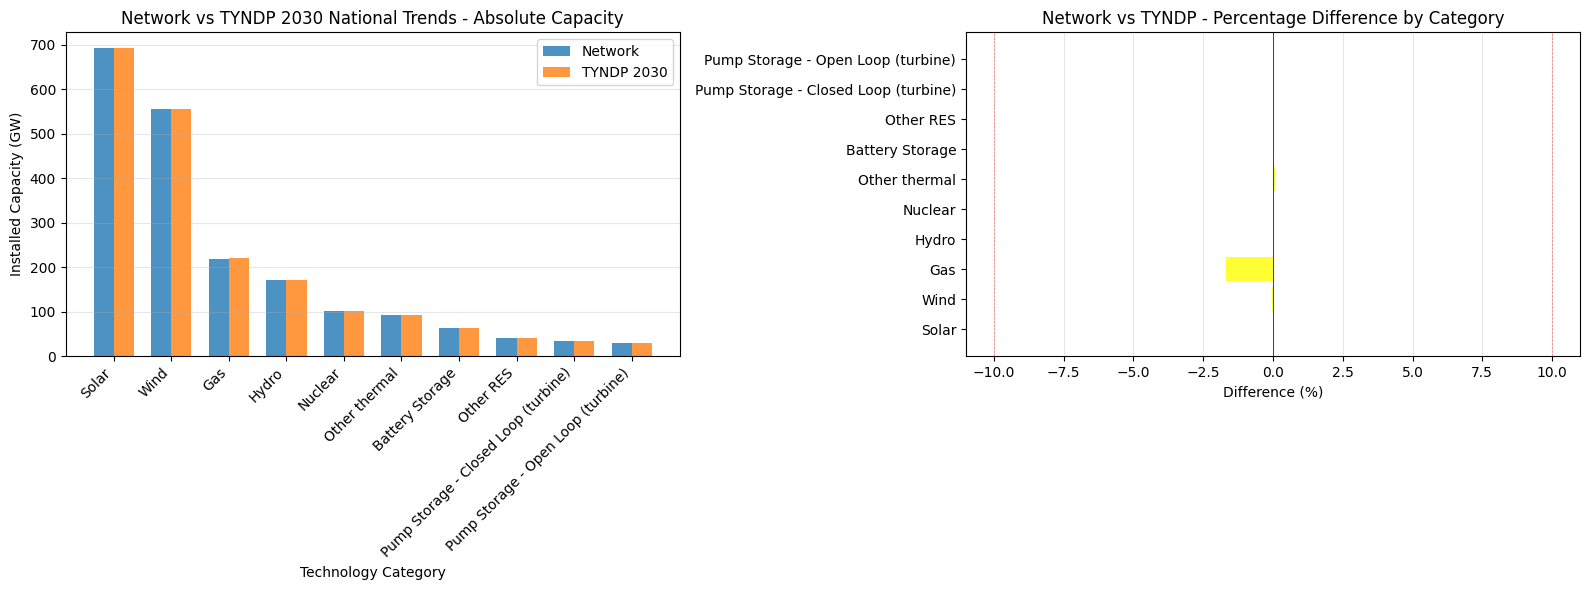

In [39]:
# Create validation visualizations
import matplotlib.pyplot as plt

# Exclude DSR for visualization
plot_data = total_summary[~total_summary['Category_Simple'].isin(['DSR Explicit', 'TOTAL', 'TOTAL (excl. DSR)'])].copy()
plot_data = plot_data.sort_values('Network', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute capacities
x = range(len(plot_data))
width = 0.35
ax1.bar([i - width/2 for i in x], plot_data['Network'], width, label='Network', alpha=0.8)
ax1.bar([i + width/2 for i in x], plot_data['TYNDP'], width, label='TYNDP 2030', alpha=0.8)
ax1.set_xlabel('Technology Category')
ax1.set_ylabel('Installed Capacity (GW)')
ax1.set_title('Network vs TYNDP 2030 National Trends - Absolute Capacity')
ax1.set_xticks(x)
ax1.set_xticklabels(plot_data['Category_Simple'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Percentage difference
colors = ['red' if x < -10 else 'orange' if x < -5 else 'yellow' if abs(x) < 5 else 'lightgreen' if x < 10 else 'green' 
          for x in plot_data['Diff %']]
ax2.barh(plot_data['Category_Simple'], plot_data['Diff %'], color=colors, alpha=0.8)
ax2.set_xlabel('Difference (%)')
ax2.set_title('Network vs TYNDP - Percentage Difference by Category')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax2.axvline(x=-10, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.axvline(x=10, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('capacity_validation.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
print(len(network.buses))
display(network.buses)

55


,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network,country
name,,,,,,,,,,,,,,
AL00,380.0,,20.036884,41.117588,AC,,,1.0,0.0,inf,PQ,,,AL
AT00,380.0,,14.822183,47.668898,AC,,,1.0,0.0,inf,PQ,,,AT
BA00,380.0,,17.867837,43.982016,AC,,,1.0,0.0,inf,PQ,,,BA
BE00,380.0,,4.967931,50.470635,AC,,,1.0,0.0,inf,PQ,,,BE
BG00,380.0,,25.323948,42.668760,AC,,,1.0,0.0,inf,PQ,,,BG
CH00,380.0,,8.416156,46.797090,AC,,,1.0,0.0,inf,PQ,,,CH
CY00,380.0,,33.008947,34.944963,AC,,,1.0,0.0,inf,PQ,,,CY
CZ00,380.0,,15.663683,49.752662,AC,,,1.0,0.0,inf,PQ,,,CZ
DE00,380.0,,10.113400,51.109915,AC,,,1.0,0.0,inf,PQ,,,DE


## Phase 6: Add Time Series

**Goal**: Expand network to 8760 hours and add time-varying electricity demand for each bus.

**Steps**:
1. Set network snapshots to full year 2030 (8760 hours)
2. Prepare demand time series (shift 2009 profile to 2030)
3. Add loads with time series for each bus
4. Validate total demand matches TYNDP expectations

In [41]:
# Step 1: Set network snapshots to full year 2030
print("Setting network snapshots to full year 2030...")

# Create 8760 hourly snapshots for 2030
snapshots_2030 = pd.date_range('2030-01-01 00:00', periods=8760, freq='h')
network.set_snapshots(snapshots_2030)

print(f"Network now has {len(network.snapshots)} snapshots")
print(f"   Start: {network.snapshots[0]}")
print(f"   End: {network.snapshots[-1]}")
print(f"\nSnapshot properties:")
print(f"   Duration: {len(network.snapshots)} hours")
print(f"   Days: {len(network.snapshots) / 24:.1f} days")

Setting network snapshots to full year 2030...
Network now has 8760 snapshots
   Start: 2030-01-01 00:00:00
   End: 2030-12-31 23:00:00

Snapshot properties:
   Duration: 8760 hours
   Days: 365.0 days


In [42]:
# Step 2: Prepare demand time series
print("\nPreparing electricity demand time series...")

# Inspect original demand data
print(f"Original demand data:")
print(f"   Shape: {electricity_demand.shape}")
print(f"   Index start: {electricity_demand.index[0]}")
print(f"   Index end: {electricity_demand.index[-1]}")
print(f"   Columns (buses): {electricity_demand.columns.tolist()}")

# Shift to 2030 (use 2009 profile as proxy)
demand_2030 = electricity_demand.copy()
demand_2030.index = pd.date_range('2030-01-01 00:00', periods=len(demand_2030), freq='h')

# Verify alignment
print(f"\nDemand 2030:")
print(f"   Shape: {demand_2030.shape}")
print(f"   Index start: {demand_2030.index[0]}")
print(f"   Index end: {demand_2030.index[-1]}")
print(f"\nDemand time series prepared for {len(demand_2030.columns)} buses")


Preparing electricity demand time series...
Original demand data:
   Shape: (8760, 63)
   Index start: 2009-01-01 00:00:00
   Index end: 2009-12-31 23:00:00
   Columns (buses): ['AL00', 'AT00', 'BA00', 'BE00', 'BG00', 'CH00', 'CY00', 'CZ00', 'DE00', 'DKE1', 'DZ00', 'DKW1', 'EE00', 'EG00', 'ES00', 'FI00', 'FR00', 'FR15', 'GE00', 'GR00', 'GR03', 'HR00', 'HU00', 'IL00', 'IE00', 'ITCA', 'ITCN', 'ITCS', 'ITN1', 'ITS1', 'ITSA', 'ITSI', 'LT00', 'LUB1', 'LUF1', 'LUG1', 'LY00', 'MD00', 'MA00', 'LV00', 'ME00', 'MK00', 'MT00', 'NL00', 'NOM1', 'NON1', 'NOS0', 'PL00', 'PS00', 'PT00', 'RO00', 'RS00', 'SE01', 'SE02', 'SE03', 'SE04', 'SI00', 'SK00', 'TN00', 'TR00', 'UA00', 'GB00', 'GBNI']

Demand 2030:
   Shape: (8760, 63)
   Index start: 2030-01-01 00:00:00
   Index end: 2030-12-31 23:00:00

Demand time series prepared for 63 buses


In [43]:
print(buses["bus_id"].unique())
print(len(buses["bus_id"].unique()))

['AL00' 'AT00' 'BA00' 'BE00' 'BG00' 'CH00' 'CY00' 'CZ00' 'DE00' 'DKE1'
 'DKW1' 'EE00' 'ES00' 'FI00' 'FR00' 'FR15' 'GB00' 'GBNI' 'GR00' 'GR03'
 'HR00' 'HU00' 'IE00' 'ITCA' 'ITCN' 'ITCS' 'ITN1' 'ITS1' 'ITSA' 'ITSI'
 'LT00' 'LUB1' 'LUF1' 'LUG1' 'LUV1' 'LV00' 'ME00' 'MK00' 'MT00' 'NL00'
 'NOM1' 'NON1' 'NOS0' 'PL00' 'PT00' 'RO00' 'RS00' 'SE01' 'SE02' 'SE03'
 'SE04' 'SI00' 'SK00' 'ITCO' 'ITVI']
55


In [44]:
# Step 3: Add loads with time series
print("Adding loads to network...")

added_loads = 0
missing_demand = []

for bus in network.buses.index:
    if bus in demand_2030.columns:
        network.add(
            "Load",
            name=f"{bus}-load",
            bus=bus,
            p_set=demand_2030[bus].values
        )
        added_loads += 1
    else:
        missing_demand.append(bus)
    #     network.add(
    #         "Load",
    #         name=f"{bus}-load",
    #         bus=bus,
    #         p_set=100.0  # 100 MW constant fallback
    #     )

print(f"Added {added_loads} loads with time series demand")
if missing_demand:
    print(f"WARNING: {len(missing_demand)} buses without demand data")
    print(f"   {missing_demand}")

print(f"Total loads in network: {len(network.loads)}")

Adding loads to network...
Added 52 loads with time series demand
   ['LUV1', 'ITCO', 'ITVI']
Total loads in network: 52
Added 52 loads with time series demand
   ['LUV1', 'ITCO', 'ITVI']
Total loads in network: 52


In [45]:
# Step 4: Validate demand
print("\nValidating electricity demand...")

# Total demand statistics
total_demand_ts = network.loads_t.p_set.sum(axis=1)  # Sum across all loads at each timestep

print(f"\nDemand statistics:")
print(f"   Mean: {total_demand_ts.mean():.0f} MW")
print(f"   Min: {total_demand_ts.min():.0f} MW")
print(f"   Max: {total_demand_ts.max():.0f} MW")
print(f"   Total annual energy: {total_demand_ts.sum() / 1000:.0f} GWh")

# Sample demand profile for a major country
print(f"\nSample demand profile for DE00 (Germany):")
if 'DE00-load' in network.loads.index:
    de_demand = network.loads_t.p_set['DE00-load']
    print(f"   Mean: {de_demand.mean():.0f} MW")
    print(f"   Min: {de_demand.min():.0f} MW")
    print(f"   Max: {de_demand.max():.0f} MW")
    print(f"\nFirst 24 hours:")
    print(de_demand.head(24))

print("\nPhase 6 complete: Time series demand added to network")


Validating electricity demand...

Demand statistics:
   Mean: 450624 MW
   Min: 271057 MW
   Max: 713978 MW
   Total annual energy: 3947469 GWh

Sample demand profile for DE00 (Germany):
   Mean: 81725 MW
   Min: 32944 MW
   Max: 152345 MW

First 24 hours:
snapshot
2030-01-01 00:00:00    75929.264658
2030-01-01 01:00:00    73368.054415
2030-01-01 02:00:00    72445.216782
2030-01-01 03:00:00    73673.191758
2030-01-01 04:00:00    77914.759672
2030-01-01 05:00:00    82688.268182
2030-01-01 06:00:00    86883.355962
2030-01-01 07:00:00    90633.049576
2030-01-01 08:00:00    89713.408962
2030-01-01 09:00:00    89254.875734
2030-01-01 10:00:00    92524.656301
2030-01-01 11:00:00    93208.162174
2030-01-01 12:00:00    92291.695226
2030-01-01 13:00:00    91046.286149
2030-01-01 14:00:00    91165.477531
2030-01-01 15:00:00    93610.849197
2030-01-01 16:00:00    97950.188739
2030-01-01 17:00:00    98713.899344
2030-01-01 18:00:00    96615.386038
2030-01-01 19:00:00    91148.605040
2030-01-01 20

## Phase 6.2: Add Renewable Profiles

**Goal**: Add time-varying capacity factors for renewable generators (wind, solar).

**Data**: Wind onshore/offshore, solar utility/rooftop capacity factor profiles (0-1).

**Next**: Apply these profiles to renewable generators' `p_max_pu`.

In [46]:
# Shift renewable profiles to 2030
wind_onshore_2030 = wind_onshore.copy()
wind_onshore_2030.index = pd.date_range('2030-01-01', periods=len(wind_onshore_2030), freq='h')

wind_offshore_2030 = wind_offshore.copy()
wind_offshore_2030.index = pd.date_range('2030-01-01', periods=len(wind_offshore_2030), freq='h')

solar_utility_2030 = solar_utility.copy()
solar_utility_2030.index = pd.date_range('2030-01-01', periods=len(solar_utility_2030), freq='h')

solar_rooftop_2030 = solar_rooftop.copy()
solar_rooftop_2030.index = pd.date_range('2030-01-01', periods=len(solar_rooftop_2030), freq='h')

In [47]:
solar_rooftop_2030.head(10)

,AL00,AT00,BA00,BE00,BG00,CH00,CY00,CZ00,DE00,DKE1,DKW1,EE00,ES00,FI00,FR00,FR15,GB00,GBNI,GR00,GR03,HR00,HU00,IE00,ITCA,ITCN,ITCS,ITN1,ITS1,ITSA,ITSI,LT00,LUB1,LUF1,LUG1,LUV1,LV00,ME00,MK00,MT00,NL00,NOM1,NON1,NOS0,PL00,PT00,RO00,RS00,SE01,SE02,SE03,SE04,SI00,SK00,ITCO,ITVI
2030-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2030-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2030-01-01 02:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2030-01-01 03:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2030-01-01 04:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2030-01-01 05:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2030-01-01 06:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.171712,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.021927,0.000000,0.000000,0.0,0.002043,0.000000,8.904284e-10,0.000000,0.000466,0.000000,0.001838,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2030-01-01 07:00:00,0.099120,0.000000,0.014675,0.000000,0.226994,0.000000,0.356087,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.171021,0.084141,0.000912,0.018761,0.0,0.079889,0.004257,1.026573e-02,0.003529,0.030396,0.017702,0.101654,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.027472,0.197179,0.068587,0.000000,0.0,0.0,0.000000,0.000635,0.000000,0.147523,0.118115,0.0,0.000000,0.000000,0.00000

In [48]:
wind_offshore_2030.head(10)

,BE00,DE00,DKE1,DKW1,ES00,FI00,FR00,GB00,GBNI,GR00,HR00,IE00,ITCN,ITCS,ITN1,ITS1,ITSA,ITSI,LT00,LV00,NL00,NOS0,PL00,PT00,RO00,SE04
2030-01-01 00:00:00,0.006736,0.236638,0.161902,0.594808,0.605975,0.922741,0.482505,0.157602,0.110723,0.733920,0.038150,0.714761,0.355367,0.304754,0.017841,0.055212,0.621261,0.735950,0.194373,0.225230,0.056180,0.678014,0.217605,0.782285,0.057370,0.187278
2030-01-01 01:00:00,0.004962,0.262659,0.184009,0.578846,0.582455,0.918446,0.440913,0.159458,0.138486,0.686058,0.044073,0.721995,0.289641,0.306470,0.003068,0.073677,0.571401,0.655615,0.202553,0.306011,0.053232,0.760109,0.242895,0.692790,0.053415,0.231050
2030-01-01 02:00:00,0.004598,0.293127,0.217224,0.552811,0.541922,0.921929,0.430248,0.157594,0.150683,0.650440,0.061428,0.748656,0.262567,0.311540,0.000038,0.095014,0.508567,0.612352,0.209820,0.404716,0.044081,0.820321,0.252767,0.644933,0.050385,0.257646
2030-01-01 03:00:00,0.006754,0.305920,0.246343,0.530000,0.480038,0.922233,0.430664,0.160796,0.152147,0.637414,0.088286,0.785644,0.248284,0.342275,0.001898,0.114969,0.435786,0.619447,0.229257,0.529568,0.040384,0.842138,0.270651,0.692265,0.043410,0.262208
2030-01-01 04:00:00,0.007690,0.316546,0.234236,0.504549,0.424258,0.904696,0.451714,0.163851,0.146125,0.645021,0.131815,0.811540,0.246607,0.347823,0.012812,0.122595,0.359448,0.661733,0.302384,0.674396,0.048526,0.786662,0.315569,0.788860,0.031264,0.307086
2030-01-01 05:00:00,0.004481,0.367638,0.236613,0.455651,0.385867,0.895551,0.466592,0.158758,0.158343,0.625698,0.213096,0.833041,0.241180,0.357956,0.026185,0.152167,0.292249,0.715655,0.458560,0.792208,0.063611,0.676087,0.409678,0.803627,0.017539,0.394353
2030-01-01 06:00:00,0.001460,0.420300,0.236886,0.360186,0.362045,0.888120,0.497376,0.151311,0.211123,0.608537,0.304102,0.851835,0.260180,0.375424,0.031220,0.177952,0.227938,0.728441,0.636553,0.846765,0.060359,0.530807,0.513485,0.802270,0.006022,0.466504
2030-01-01 07:00:00,0.000479,0.462518,0.216519,0.255139,0.347347,0.894882,0.531512,0.145292,0.267036,0.571365,0.386312,0.864443,0.257470,0.412731,0.079801,0.204185,0.181459,0.730782,0.785685,0.887499,0.046989,0.380485,0.603455,0.857790,0.003238,0.524054
2030-01-01 08:00:00,0.000400,0.405386,0.178915,0.168157,0.339761,0.859196,0.549545,0.143277,0.284268,0.521518,0.495496,0.872034,0.235355,0.417484,0.211084,0.234145,0.164346,0.745859,0.862818,0.895564,0.030407,0.233043,0.674454,0.871655,0.006814,0.554831
2030-01-01 09:00:00,0.000644,0.325474,0.162257,0.122601,0.338373,0.756487,0.564128,0.147882,0.275710,0.474491,0.648304,0.866413,0.205748,0.425568,0.352371,0.299305,0.161123,0.754943,0.897030,0.857497,0.017823,0.132567,0.747201,0.887777,0.018960,0.582187


In [49]:
# Step 3: Apply availability profiles for renewable generators
print("Applying renewable availability profiles...")

PROFILE_MAP = {
    'onwind':            wind_onshore_2030,
    'offwind':           wind_offshore_2030,
    'solar-pv-utility':  solar_utility_2030,
    'solar-pv-rooftop':  solar_rooftop_2030,
}

applied_renewables = {c: 0 for c in PROFILE_MAP}
no_profile = []


for gen_name in network.generators.index:
    bus     = network.generators.loc[gen_name, 'bus']
    carrier = network.generators.loc[gen_name, 'carrier']

    if carrier not in PROFILE_MAP:
        continue

    if bus in PROFILE_MAP[carrier].columns:
        # Clip to [0, 1]: PECD data can have small negative float artifacts at night
        cf = PROFILE_MAP[carrier][bus].values.clip(0.0, 1.0)
        network.generators_t.p_max_pu[gen_name] = cf
        applied_renewables[carrier] += 1
    else:
        # Bus has no profile data, set to 0 (cannot generate)
        network.generators_t.p_max_pu[gen_name] = 0.0
        no_profile.append((gen_name, carrier, bus))

print("Applied VRE profiles:")
for carrier, count in applied_renewables.items():
    print(f"  {carrier:<22}: {count} generators")

if no_profile:
    print(f"\nWARNING: {len(no_profile)} generators without profile data (set to 0.0):")
    for name, c, b in no_profile:
        print(f"  {name} ({c} @ {b})")



Applying renewable availability profiles...
Applied VRE profiles:
  onwind                : 49 generators
  offwind               : 26 generators
  solar-pv-utility      : 40 generators
  solar-pv-rooftop      : 36 generators


In [50]:
display(network.generators["carrier"].unique())

array(['gas', 'oil-light', 'lignite', 'coal', 'nuclear', 'oil-heavy',
       'oil-shale', 'gas-ccs', 'hydro-ror', 'onwind', 'solar-pv-utility',
       'solar-pv-rooftop', 'other-thermal', 'other-res', 'offwind',
       'solar-thermal', 'h2-fuel-cell', 'h2-ccgt',
       'solar-thermal-w-storage'], dtype=object)

In [51]:
# VRE profile coverage summary: CSV columns vs network generators
print(f"{'Carrier':<22}  {'CSV cols':>9}  {'all-zero':>9}  {'net gens':>9}  {'no profile':>10}  {'in CSV not net':>15}  {'in net not CSV':>15}")
print("-" * 100)

checks = {
    'onwind':           wind_onshore_2030,
    'offwind':          wind_offshore_2030,
    'solar-pv-utility': solar_utility_2030,
    'solar-pv-rooftop': solar_rooftop_2030,
}

for carrier, df in checks.items():
    csv_cols   = set(df.columns)
    all_zero   = [c for c in df.columns if (df[c] == 0).all()]
    net_buses  = set(network.generators[network.generators['carrier'] == carrier]['bus'])
    no_profile = sorted(net_buses - csv_cols)
    only_csv   = sorted((csv_cols - set(all_zero)) - net_buses)  # non-zero CSV cols missing from network

    print(f"  {carrier:<22}  {len(csv_cols):>9}  {len(all_zero):>9}  {len(net_buses):>9}  {len(no_profile):>10}  "
          f"{str(only_csv) if only_csv else '—':<40}  {str(no_profile) if no_profile else '—'}")


Carrier                  CSV cols   all-zero   net gens  no profile   in CSV not net   in net not CSV
----------------------------------------------------------------------------------------------------
  onwind                         55          6         49           0  —                                         —
  offwind                        26          0         26           0  —                                         —
  solar-pv-utility               55          7         40           0  ['BE00', 'CH00', 'NOM1', 'NOS0', 'SE02', 'SE03', 'SE04', 'SI00']  —
  solar-pv-rooftop               55          7         36           0  ['AL00', 'BA00', 'EE00', 'FR00', 'FR15', 'GR00', 'GR03', 'HR00', 'LT00', 'ME00', 'PL00', 'SK00']  —


In [52]:

# Step 4: Apply thermal generator availability
#
# Each thermal generator gets p_max_pu from THERMAL_DERATING (per-carrier derating factor).
# Falls back to THERMAL_DEFAULT_AVAIL = 1 for carriers not in the derating dict.
# (electrolyser, h2, and other-res excluded — other-res gets hourly profiles in Step 5)

THERMAL_DERATING = {
    "coal":          1,  # planned outages + forced, large capacity
    "coal-ccs":      1,
    "gas":           1,
    "gas-ccs":       1,
    "gas-ccgt":      1,
    "gas-ocgt":      1,  # small peakers, low slack risk
    "lignite":       1,  # large DE/PL capacity, realistic availability
    "lignite-ccs":   1,
    "oil-heavy":     1,     # small capacity, keep at 1
    "oil-light":     1,     # small capacity, keep at 1
    "oil-shale":     1,     # only EE, small
    # "nuclear":       0.8,
    "h2-ccgt":       1,
    "other-thermal": 1,  # CHP: realistic ~90% availability
    "h2-fuel-cell":  1,
}

# other-res excluded here — it gets proper hourly p_max_pu profiles in Step 5
THERMAL_CARRIERS = [c for c in CONVENTIONAL_CARRIERS if c not in ("electrolyser", "h2", "other-res", "nuclear")]
THERMAL_DEFAULT_AVAIL = 1

print("Applying thermal generator availability (p_max_pu from THERMAL_DERATING or default)...")

applied_thermal = 0
not_applied = 0
not_applied_carriers = set()

for gen_name in network.generators.index:
    carrier = network.generators.loc[gen_name, 'carrier']

    if carrier not in THERMAL_CARRIERS:
        not_applied += 1
        not_applied_carriers.add(carrier)
        continue

    avail = THERMAL_DERATING.get(carrier, THERMAL_DEFAULT_AVAIL)
    network.generators_t.p_max_pu[gen_name] = avail
    applied_thermal += 1

print(f"  Applied p_max_pu from THERMAL_DERATING to {applied_thermal} generators")
print(f"  Carriers covered: {THERMAL_CARRIERS}")
print(f"  Not applied to: {not_applied} generators")
print(f"  Not applied these: {not_applied_carriers} generators")

# Summary of derating values applied
from collections import Counter
derating_summary = Counter(
    THERMAL_DERATING.get(network.generators.loc[g, 'carrier'], THERMAL_DEFAULT_AVAIL)
    for g in network.generators.index
    if network.generators.loc[g, 'carrier'] in THERMAL_CARRIERS
)
print(f"\n  Derating value distribution: {dict(sorted(derating_summary.items()))}")


Applying thermal generator availability (p_max_pu from THERMAL_DERATING or default)...
  Applied p_max_pu from THERMAL_DERATING to 173 generators
  Carriers covered: ['coal', 'coal-ccs', 'gas', 'gas-ccs', 'h2-ccgt', 'lignite', 'lignite-ccs', 'oil-heavy', 'oil-light', 'oil-shale', 'other-thermal']
  Not applied to: 253 generators
  Not applied these: {'h2-fuel-cell', 'offwind', 'solar-pv-rooftop', 'solar-pv-utility', 'onwind', 'hydro-ror', 'other-res', 'solar-thermal', 'solar-thermal-w-storage', 'nuclear'} generators

  Derating value distribution: {1: 173}


In [53]:
# Step 4b: Apply hourly nuclear p_max_pu profiles from TYNDP 2024
#
# Source: nuclear_p_max_pu_2030.csv
#   - Derived from normalized TYNDP 2024 Market Output generation time series
#   - Resampled weekly (max per week) to capture maintenance schedules + forced outages
#   - Climate year 2009, mapped to network snapshot year (2030)
#   - 100% bus overlap with nuclear generators in network (14/14 buses)

print("Applying hourly nuclear p_max_pu profiles from nuclear_p_max_pu_2030.csv...")

nuclear_profiles_raw = pd.read_csv(
    DATA_DIR / "nuclear_p_max_pu_2030.csv",
    index_col=0,
    parse_dates=True,
)

# Remap CY2009 timestamps → network snapshot year
snapshot_year = network.snapshots[0].year
nuclear_profiles_raw.index = nuclear_profiles_raw.index.map(
    lambda t: t.replace(year=snapshot_year)
)

# Reindex to exact network snapshots (ffill fills within-week gaps from weekly resampling)
nuclear_profiles = nuclear_profiles_raw.reindex(network.snapshots, method="ffill")

applied_nuclear = 0

for gen_name in network.generators.index:
    if network.generators.loc[gen_name, 'carrier'] != 'nuclear':
        continue
    bus = network.generators.loc[gen_name, 'bus']
    if bus in nuclear_profiles.columns:
        network.generators_t.p_max_pu[gen_name] = nuclear_profiles[bus].values
        applied_nuclear += 1
    else:
        # Should never happen — 100% bus overlap confirmed
        network.generators_t.p_max_pu[gen_name] = 0.8
        print(f"  WARNING: no nuclear profile for bus {bus}, using fallback 0.8")

print(f"  Applied hourly nuclear profiles to {applied_nuclear} generators")

# Spot-check: FR00 monthly means
fr_gens = [g for g in network.generators.index
           if network.generators.loc[g, 'carrier'] == 'nuclear'
           and network.generators.loc[g, 'bus'] == 'FR00']
if fr_gens:
    fr_profile = network.generators_t.p_max_pu[fr_gens[0]]
    monthly = fr_profile.groupby(fr_profile.index.month).mean().round(3)
    print(f"\nFR00 nuclear p_max_pu monthly means (spot-check):")
    for m, v in monthly.items():
        print(f"  Month {m:2d}: {v:.3f}")
    print(f"  Annual mean: {fr_profile.mean():.3f}")

Applying hourly nuclear p_max_pu profiles from nuclear_p_max_pu_2030.csv...
  Applied hourly nuclear profiles to 14 generators

FR00 nuclear p_max_pu monthly means (spot-check):
  Month  1: 0.832
  Month  2: 0.787
  Month  3: 0.719
  Month  4: 0.684
  Month  5: 0.680
  Month  6: 0.654
  Month  7: 0.667
  Month  8: 0.647
  Month  9: 0.681
  Month 10: 0.688
  Month 11: 0.725
  Month 12: 0.795
  Annual mean: 0.713
  Applied hourly nuclear profiles to 14 generators

FR00 nuclear p_max_pu monthly means (spot-check):
  Month  1: 0.832
  Month  2: 0.787
  Month  3: 0.719
  Month  4: 0.684
  Month  5: 0.680
  Month  6: 0.654
  Month  7: 0.667
  Month  8: 0.647
  Month  9: 0.681
  Month 10: 0.688
  Month 11: 0.725
  Month 12: 0.795
  Annual mean: 0.713


In [54]:

# Step 5: Apply other-res hourly p_max_pu profiles (from PEMMDB)
#
# other-res generators were added with p_max_pu=1.0 but their real capacity
# factor (~0.6) is much lower because they contain biomass, waste, etc.
# We apply the proper hourly timeseries computed in create_other_res_dataset.ipynb.

# Load aggregated other-res p_max_pu timeseries (8760h × nodes)
other_res_pmax = pd.read_csv(
    DATA_DIR / "other_res_p_max_pu.csv",
    index_col=0,
    parse_dates=True
)
other_res_pmax = other_res_pmax.rename(columns={"UK00": "GB00", "UKNI": "GBNI"})
other_res_pmax.index = network.snapshots

# Get all other-res generators
other_res_gens = network.generators[network.generators["carrier"] == "other-res"]
print(other_res_gens.index)
print(f"other-res generators in network: {len(other_res_gens)}")

FALLBACK_CF = 0.60  # fallback if node not in PEMMDB dataset

applied_other_res = 0
applied_other_res_nodes = set()
fallback_other_res = 0
fallback_other_res_nodes = set()

for gen_name, gen_row in other_res_gens.iterrows():
    node = gen_row["bus"]  # e.g. "DE00"
    if node in other_res_pmax.columns:
        network.generators_t.p_max_pu[gen_name] = other_res_pmax[node].values
        applied_other_res += 1
        applied_other_res_nodes.add(node)
    else:
        network.generators_t.p_max_pu[gen_name] = FALLBACK_CF
        fallback_other_res_nodes.add(node)
        fallback_other_res += 1

print(f"  Applied hourly profile : {applied_other_res} generators")
print(applied_other_res_nodes)
print(f"  Applied fallback CF={FALLBACK_CF}: {fallback_other_res} generators")
print(fallback_other_res_nodes)

# Validation: check DE00
de_other = other_res_gens[other_res_gens["bus"] == "DE00"]
if not de_other.empty:
    gen_name_de = de_other.index[0]
    ts = network.generators_t.p_max_pu[gen_name_de]
    cap = de_other.loc[gen_name_de, "p_nom"]
    annual_twh = ts.sum() * cap / 1e6
    print(f"\n  DE00 other-res validation:")
    print(f"    p_nom     = {cap:.0f} MW")
    print(f"    mean CF   = {ts.mean():.3f}")
    print(f"    annual    = {annual_twh:.1f} TWh  (TYNDP target: ~70 TWh)")


Index(['AT00-other-res', 'BE00-other-res', 'BG00-other-res', 'CH00-other-res',
       'CY00-other-res', 'CZ00-other-res', 'DE00-other-res', 'DKW1-other-res',
       'EE00-other-res', 'ES00-other-res', 'FI00-other-res', 'FR00-other-res',
       'FR15-other-res', 'GB00-other-res', 'GBNI-other-res', 'GR00-other-res',
       'HR00-other-res', 'HU00-other-res', 'IE00-other-res', 'ITCA-other-res',
       'ITCN-other-res', 'ITCS-other-res', 'ITN1-other-res', 'ITS1-other-res',
       'ITSA-other-res', 'ITSI-other-res', 'LT00-other-res', 'LUG1-other-res',
       'LV00-other-res', 'ME00-other-res', 'MK00-other-res', 'NL00-other-res',
       'PL00-other-res', 'PT00-other-res', 'RO00-other-res', 'RS00-other-res',
       'SE01-other-res', 'SE02-other-res', 'SE03-other-res', 'SE04-other-res',
       'SI00-other-res', 'SK00-other-res'],
      dtype='object', name='name')
other-res generators in network: 42
  Applied hourly profile : 42 generators
{'IE00', 'GB00', 'RS00', 'BG00', 'GBNI', 'BE00', 'LUG1

In [55]:
pd.set_option('display.max_rows', 500)
display(network.buses.index)

Index(['AL00', 'AT00', 'BA00', 'BE00', 'BG00', 'CH00', 'CY00', 'CZ00', 'DE00',
       'DKE1', 'DKW1', 'EE00', 'ES00', 'FI00', 'FR00', 'FR15', 'GB00', 'GBNI',
       'GR00', 'GR03', 'HR00', 'HU00', 'IE00', 'ITCA', 'ITCN', 'ITCS', 'ITN1',
       'ITS1', 'ITSA', 'ITSI', 'LT00', 'LUB1', 'LUF1', 'LUG1', 'LUV1', 'LV00',
       'ME00', 'MK00', 'MT00', 'NL00', 'NOM1', 'NON1', 'NOS0', 'PL00', 'PT00',
       'RO00', 'RS00', 'SE01', 'SE02', 'SE03', 'SE04', 'SI00', 'SK00', 'ITCO',
       'ITVI'],
      dtype='object', name='name')

In [56]:
print(HYDRO_CARRIERS)

['hydro-ror', 'hydro-phs', 'hydro-phs-pure', 'hydro-pondage', 'hydro-reservoir']


In [57]:
# Step 5a: Apply hydro run-of-river capacity factors (Generator.p_max_pu)
#
# hydro_ror inflow data is in MW, columns = bus codes (AT00, NOM1, ITCA …).
# Each bus has exactly one RoR generator, so:
#   CF = inflow_bus [MW] / p_nom_gen [MW]
print("Applying hydro run-of-river capacity factors (Generator.p_max_pu)...")

# Re-index inflow data to 2030
hydro_ror_2030 = hydro_ror.copy()
hydro_ror_2030.index = pd.date_range('2030-01-01', periods=len(hydro_ror_2030), freq='h')

ror_gens = network.generators[network.generators.carrier.isin(HYDRO_ROR_CARRIERS)].copy()

applied_ror = 0
no_profile_ror = []

for gen_name, row in ror_gens.iterrows():
    bus = row['bus']
    p_nom = row['p_nom']
    if bus in hydro_ror_2030.columns and p_nom > 0:
        cf = (hydro_ror_2030[bus].values / p_nom).clip(0, 1)
        network.generators_t.p_max_pu[gen_name] = cf
        applied_ror += 1
    else:
        no_profile_ror.append((gen_name, bus, "no data" if bus not in hydro_ror_2030.columns else "p_nom=0"))

print(f"  Applied p_max_pu profile : {applied_ror} RoR generators")
if no_profile_ror:
    print(f"  Skipped ({len(no_profile_ror)}):")
    for name, b, reason in no_profile_ror:
        print(f"    {name:<35}  bus={b}  reason={reason}")
else:
    print("  Skipped                  : 0")


Applying hydro run-of-river capacity factors (Generator.p_max_pu)...
  Applied p_max_pu profile : 37 RoR generators
  Skipped                  : 0


In [58]:
# Step 5b: Apply hydro inflows to StorageUnits (StorageUnit.inflow)
#
# Inflow data columns = bus codes (AT00, NOM1, ITCA …), values in MW.
# Each StorageUnit gets: unit_inflow = bus_inflow × (unit_p_nom / total_bus_p_nom)
# Mapping:
#   hydro-reservoir → hydro_reservoir   (large reservoir, seasonal)
#   hydro-pondage   → hydro_pondage     (small reservoir, daily/weekly)
#   hydro-phs       → hydro_ps_open     (open-loop PHS, natural inflow)
#   hydro-phs-pure  → no inflow         (closed-loop PHS, no natural water)
print("Applying hydro inflows to StorageUnits (StorageUnit.inflow)...")

INFLOW_MAP = {
    'hydro-reservoir': hydro_reservoir,
    'hydro-pondage':   hydro_pondage,
    'hydro-phs':       hydro_ps_open,
    # hydro-phs-pure: closed-loop → no natural inflow
}

# Re-index all inflow DataFrames to 2030
inflow_2030 = {
    carrier: df.copy().set_axis(
        pd.date_range('2030-01-01', periods=len(df), freq='h')
    )
    for carrier, df in INFLOW_MAP.items()
}

applied_su = 0
no_profile_su = []

for carrier, inflow_df in inflow_2030.items():
    units = network.storage_units[network.storage_units['carrier'] == carrier].copy()
    if units.empty:
        continue

    # Total p_nom per bus for proportional allocation
    bus_total = units.groupby('bus')['p_nom'].sum()

    for su_name, row in units.iterrows():
        bus = row['bus']
        if bus not in inflow_df.columns:
            no_profile_su.append((su_name, carrier, bus, "no data"))
            continue

        total_p = bus_total[bus]
        if total_p <= 0:
            no_profile_su.append((su_name, carrier, bus, "p_nom=0"))
            continue

        share = row['p_nom'] / total_p
        unit_inflow = (inflow_df[bus].values * share).clip(min=0)
        network.storage_units_t.inflow[su_name] = unit_inflow
        applied_su += 1

print(f"  Applied inflow profile   : {applied_su} StorageUnits")
if no_profile_su:
    print(f"  Skipped ({len(no_profile_su)}):")
    for name, c, bus, reason in no_profile_su:
        print(f"    {name:<40}  carrier={c}  bus={bus}  reason={reason}")
else:
    print("  Skipped                  : 0")

# Summary table
print(f"\n  {'CARRIER':<20} {'UNITS':>6} {'WITH INFLOW':>12} {'ANNUAL ENERGY':>16}")
print(f"  {'-'*58}")
for carrier in list(INFLOW_MAP.keys()) + ['hydro-phs-pure']:
    units = network.storage_units[network.storage_units['carrier'] == carrier]
    with_inflow = sum(
        1 for su in units.index
        if su in network.storage_units_t.inflow.columns
        and network.storage_units_t.inflow[su].sum() > 0
    )
    total_inflow_twh = sum(
        network.storage_units_t.inflow[su].sum()
        for su in units.index
        if su in network.storage_units_t.inflow.columns
    ) / 1e6
    print(f"  {carrier:<20} {len(units):>6} {with_inflow:>12} {total_inflow_twh:>14.1f} TWh")


Applying hydro inflows to StorageUnits (StorageUnit.inflow)...
  Applied inflow profile   : 63 StorageUnits
  Skipped                  : 0

  CARRIER               UNITS  WITH INFLOW    ANNUAL ENERGY
  ----------------------------------------------------------
  hydro-reservoir          35           33          321.1 TWh
  hydro-pondage             8            8           14.4 TWh
  hydro-phs                20           18           22.7 TWh
  hydro-phs-pure           21            0            0.0 TWh
  Applied inflow profile   : 63 StorageUnits
  Skipped                  : 0

  CARRIER               UNITS  WITH INFLOW    ANNUAL ENERGY
  ----------------------------------------------------------
  hydro-reservoir          35           33          321.1 TWh
  hydro-pondage             8            8           14.4 TWh
  hydro-phs                20           18           22.7 TWh
  hydro-phs-pure           21            0            0.0 TWh


In [59]:
# Summary of time series application
print("=" * 60)
print("TIME SERIES APPLICATION SUMMARY")
print("=" * 60)
print(f"\nNetwork now has {len(network.snapshots)} hourly snapshots for 2030")
print(f"\nTime series applied:")
print(f"   Loads: {len([l for l in network.loads.index if l in network.loads_t.p_set.columns])} / {len(network.loads)}")
print(f"   Generators (p_max_pu): {len([g for g in network.generators.index if g in network.generators_t.p_max_pu.columns])} / {len(network.generators)}")
print(f"   Storage (inflow): {len([s for s in network.storage_units.index if s in network.storage_units_t.inflow.columns])} / {len(network.storage_units)}")

print(f"\nSample data validation:")
print(f"   Total load (mean): {network.loads_t.p_set.sum(axis=1).mean():.0f} MW")
print(f"   Total load (max): {network.loads_t.p_set.sum(axis=1).max():.0f} MW")
print(f"   Total load (min): {network.loads_t.p_set.sum(axis=1).min():.0f} MW")

print(f"\nNetwork is now ready for optimization!")

TIME SERIES APPLICATION SUMMARY

Network now has 8760 hourly snapshots for 2030

Time series applied:
   Loads: 52 / 52
   Generators (p_max_pu): 417 / 426
   Storage (inflow): 63 / 119

Sample data validation:
   Total load (mean): 450624 MW
   Total load (max): 713978 MW
   Total load (min): 271057 MW

Network is now ready for optimization!


## Adding Demand Side Response

In [60]:

CLIMATE_YEAR_DSR = 2009

# PEMMDB uses UK00, network uses GB00
DSR_NODE_MAP = {"UK00": "GB00", "UKNI": "GBNI"}

# Add DSR carrier (no CO2 emissions)
network.add("Carrier", "dsr", nice_name="Demand Side Response", color="#f97316", co2_emissions=0.0)

# Load and filter DSR static data for climate year 2009
dsr_df = pd.read_csv(DATA_DIR / "dsr_pemmdb.csv")
dsr_df = dsr_df[
    (dsr_df["Climate year start"] <= CLIMATE_YEAR_DSR) &
    (dsr_df["Climate year end"]   >= CLIMATE_YEAR_DSR) &
    (dsr_df["Capacity"] > 0)
].copy()

# Remap node names to match network bus names
dsr_df["node"] = dsr_df["node"].replace(DSR_NODE_MAP)

print(f"DSR bands valid for CY{CLIMATE_YEAR_DSR}: {len(dsr_df)}")

# Load p_max_pu timeseries — columns are "{node}_{price_band}", index = 2030 timestamps
dsr_ts = pd.read_csv(DATA_DIR / "dsr_p_max_pu_timeseries.csv", index_col=0, parse_dates=True)
dsr_ts.index = network.snapshots
# Also remap timeseries column names (UK00_... → GB00_...)
dsr_ts.columns = [
    DSR_NODE_MAP.get(c.split("_")[0], c.split("_")[0]) + "_" + "_".join(c.split("_")[1:])
    for c in dsr_ts.columns
]

# Cross-check: which bands in dsr_df have no matching timeseries column?
expected_cols = dsr_df["node"] + "_" + dsr_df["price_band"]
missing = expected_cols[~expected_cols.isin(dsr_ts.columns)]
if not missing.empty:
    print(f"\n⚠ {len(missing)} band(s) in dsr_pemmdb.csv with no timeseries column:")
    for m in missing.values:
        print(f"  - {m}")

dsr_by_node = dsr_df.groupby("node")

added_dsr = 0
skipped_dsr = 0

for bus in network.buses.index:
    if bus not in dsr_by_node.groups:
        continue

    for _, row in dsr_by_node.get_group(bus).iterrows():
        price_band = row["price_band"]
        name = f"{bus}-dsr-{price_band.replace(' ', '_')}"

        ts_col = f"{bus}_{price_band}"
        if ts_col in dsr_ts.columns:
            p_max_pu = dsr_ts[ts_col]
        else:
            skipped_dsr += 1
            continue

        network.add(
            "Generator",
            name=name,
            bus=bus,
            carrier="dsr",
            p_nom=row["Capacity"],        # MW
            p_nom_extendable=False,
            marginal_cost=row["Price"],   # €/MWh
            p_max_pu=p_max_pu,
        )
        added_dsr += 1

print(f"\nAdded   : {added_dsr} DSR generators")
print(f"Skipped : {skipped_dsr} (no timeseries match)")
print(f"\nDSR capacity by node [MW]:")
dsr_gens = network.generators[network.generators.carrier == "dsr"]
print(dsr_gens.groupby("bus")["p_nom"].sum().sort_values(ascending=False).to_string())
print(f"\nMax annual DSR energy per node [TWh] (p_nom × Hours):")
dsr_gens_full = dsr_df.copy()
dsr_gens_full["max_energy_MWh"] = dsr_gens_full["Capacity"] * dsr_gens_full["Hours"]
print((dsr_gens_full.groupby("node")["max_energy_MWh"].sum() / 1e6).sort_values(ascending=False).to_string())


DSR bands valid for CY2009: 78


Added   : 78 DSR generators
Skipped : 0 (no timeseries match)

DSR capacity by node [MW]:
bus
DE00    23799.800000
GB00     7438.914697
NOS0     5968.292125
FR00     4999.400000
FI00     4640.831576
BE00     2829.660621
NOM1     2037.545788
NL00     1687.000000
NON1     1562.614469
ES00     1000.000000
SE03      936.600000
AT00      700.000000
IE00      667.000000
SE02      323.400000
SE04      264.600000
GR00      250.000000
SE01      214.200000
EE00      198.000000
LV00      150.000000
HR00       57.000000
SI00       55.000000
LUG1       45.000000
LT00       40.000000

Max annual DSR energy per node [TWh] (p_nom × Hours):
node
DE00    0.562088
FR00    0.070711
GB00    0.059511
FI00    0.055822
NOS0    0.047746
NL00    0.040488
BE00    0.033578
SE03    0.022478
AT00    0.016800
NOM1    0.016300
NON1    0.012501
SE02    0.007762
SE04    0.006350
SE01    0.005141
IE00    0.004920
EE00    0.004752
LV00    0.003600
ES00    0.003000
GR00    0.001500
HR00   

In [61]:
# Save the network before optimization
output_file = "tyndp2024_network_2030_preoptimization.nc"
network.export_to_netcdf(output_file)
print(f"Network saved to: {output_file}")
print(f"   File size: {os.path.getsize(output_file) / 1024 / 1024:.1f} MB")

INFO:pypsa.network.io:Exported network 'TYNDP2024_Electricity_2030' saved to 'tyndp2024_network_2030_preoptimization.nc contains: carriers, buses, generators, links, storage_units, loads
INFO:pypsa.network.io:Exported network 'TYNDP2024_Electricity_2030' saved to 'tyndp2024_network_2030_preoptimization.nc contains: carriers, buses, generators, links, storage_units, loads


Network saved to: tyndp2024_network_2030_preoptimization.nc
   File size: 12.8 MB


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x1581a4710>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x15817d400>},
 'flows': {}}

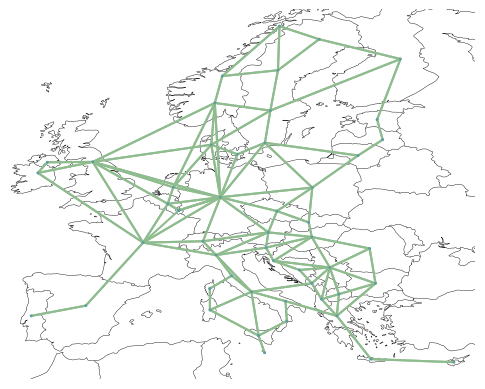

In [62]:
network.plot(geomap=True)

## Phase 7: Optimization

Run linear optimal power flow (LOPF) to optimize network operation.
Solving in file `solving.ipynb`